## 物体检测

批量标注网站推荐：labelimg  、  makesense

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

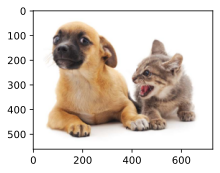

In [3]:
d2l.set_figsize()
img = d2l.plt.imread('../data/img/catdog.jpg')
d2l.plt.imshow(img);

In [7]:
"""从（左上，右下）转换到（中间，宽度，高度）"""
def box_corner_to_center(boxes):
    x1,y1,x2,y2 = boxes[:, 0], boxes[:,1], boxes[:,2], boxes[:,3]
    # 每一行是一个框 每一列是x1y1 x2y2
    # sklearn.model_selection import train_test_split 是x1x2y1y2
    cx = (x1 + x2)/2
    cy = (y1+y2)/2
    w = x2-x1
    h = y2-y1
    boxes = torch.stack((cx,cy,w,h), axis=-1)
    return boxes

#@save
def box_center_to_corner(boxes):
    """从（中间，宽度，高度）转换到（左上，右下）"""
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    boxes = torch.stack((x1, y1, x2, y2), axis=-1)
    return boxes

In [8]:
# bbox是边界框的英文缩写
dog_bbox, cat_bbox = [60.0, 45.0, 378.0, 516.0], [400.0, 112.0, 655.0, 493.0]

In [17]:
 torch.tensor([60.0, 45.0, 378.0, 516.0])[:,0]

IndexError: too many indices for tensor of dimension 1

In [18]:
 torch.tensor(([60.0, 45.0, 378.0, 516.0]))[:,0]

IndexError: too many indices for tensor of dimension 1

In [20]:
 torch.tensor([[60.0, 45.0, 378.0, 516.0]])[:,0]  # 多一个【】是可以的, 多一个（）不可以

tensor([60.])

In [19]:
torch.tensor((dog_bbox, cat_bbox))

tensor([[ 60.,  45., 378., 516.],
        [400., 112., 655., 493.]])

In [9]:
boxes = torch.tensor((dog_bbox, cat_bbox))
box_center_to_corner(box_corner_to_center(boxes)) == boxes

tensor([[True, True, True, True],
        [True, True, True, True]])

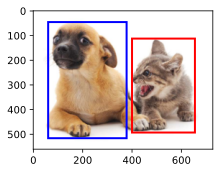

In [44]:
def bbox_to_rect(bbox, color): # 左上+宽高的表示
    return d2l.plt.Rectangle(xy=(bbox[0],bbox[1]),
                            width = bbox[2]-bbox[0],
                            height=bbox[3]-bbox[1],fill=False, # 否则内部有填充就会遮住的
                             edgecolor = color, linewidth=2) 
fig  = d2l.plt.imshow(img)
fig.axes.add_patch(bbox_to_rect(dog_bbox,'b'))
fig.axes.add_patch(bbox_to_rect(cat_bbox,'r'))

In [14]:
%matplotlib inline
import os
import pandas as pd
import torch
import torchvision
from d2l import torch as d2l

#@save
d2l.DATA_HUB['banana-detection'] = (
    d2l.DATA_URL + 'banana-detection.zip',
    '5de26c8fce5ccdea9f91267273464dc968d20d72')

In [21]:
#@save
# torchvision.io.read_image 用来读取jpg/png 转化为数组
def read_data_bananas(is_train=True):
    """读取香蕉检测数据集中的图像和标签"""
    data_dir = d2l.download_extract('banana-detection')
    csv_fname = os.path.join(data_dir, 'bananas_train' if is_train
                             else 'bananas_val', 'label.csv')
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(torchvision.io.read_image(
            os.path.join(data_dir, 'bananas_train' if is_train else
                         'bananas_val', 'images', f'{img_name}')))
        # 这里的target包含（类别，左上角x，左上角y，右下角x，右下角y），
        # 其中所有图像都具有相同的香蕉类（索引为0）
        targets.append(list(target))
    return images, torch.tensor(targets).unsqueeze(1) / 256 #除以高宽（此数据集为256 * 256）

In [49]:
csvdata = pd.read_csv(r"E:\postgraduate\python\data\banana-detection\bananas_train\label.csv")
csvdata.head()

,img_name,label,xmin,ymin,xmax,ymax
0,0.png,0,104,20,143,58
1,1.png,0,68,175,118,223
2,2.png,0,163,173,218,239
3,3.png,0,48,157,84,201
4,4.png,0,32,34,90,86


In [51]:
csvdata.set_index('img_name').head()

,label,xmin,ymin,xmax,ymax
img_name,,,,,
0.png,0,104,20,143,58
1.png,0,68,175,118,223
2.png,0,163,173,218,239
3.png,0,48,157,84,201
4.png,0,32,34,90,86


In [59]:
 [*csvdata.iterrows()][:3]

[(0,
  img_name    0.png
  label           0
  xmin          104
  ymin           20
  xmax          143
  ymax           58
  Name: 0, dtype: object),
 (1,
  img_name    1.png
  label           0
  xmin           68
  ymin          175
  xmax          118
  ymax          223
  Name: 1, dtype: object),
 (2,
  img_name    2.png
  label           0
  xmin          163
  ymin          173
  xmax          218
  ymax          239
  Name: 2, dtype: object)]

In [60]:
 [*csvdata.set_index('img_name').iterrows()][:3]

[('0.png',
  label      0
  xmin     104
  ymin      20
  xmax     143
  ymax      58
  Name: 0.png, dtype: int64),
 ('1.png',
  label      0
  xmin      68
  ymin     175
  xmax     118
  ymax     223
  Name: 1.png, dtype: int64),
 ('2.png',
  label      0
  xmin     163
  ymin     173
  xmax     218
  ymax     239
  Name: 2.png, dtype: int64)]

In [65]:
 [*csvdata.set_index('img_name').iterrows()][:3][0][1] # 这是一个series

label      0
xmin     104
ymin      20
xmax     143
ymax      58
Name: 0.png, dtype: int64

In [66]:
list( [*csvdata.set_index('img_name').iterrows()][:3][0][1])  # 沐神精彩的代码

[0, 104, 20, 143, 58]

In [58]:
[*csvdata.itertuples()][:5]

[Pandas(Index=0, img_name='0.png', label=0, xmin=104, ymin=20, xmax=143, ymax=58),
 Pandas(Index=1, img_name='1.png', label=0, xmin=68, ymin=175, xmax=118, ymax=223),
 Pandas(Index=2, img_name='2.png', label=0, xmin=163, ymin=173, xmax=218, ymax=239),
 Pandas(Index=3, img_name='3.png', label=0, xmin=48, ymin=157, xmax=84, ymax=201),
 Pandas(Index=4, img_name='4.png', label=0, xmin=32, ymin=34, xmax=90, ymax=86)]

In [23]:
import numpy as np
np.newaxis

In [25]:
x = torch.tensor([1,2,3])
x.reshape(-1,1),x.reshape(-1,1).shape

(tensor([[1],
         [2],
         [3]]),
 torch.Size([3, 1]))

In [27]:
x[:,np.newaxis],x[:,np.newaxis].shape

(tensor([[1],
         [2],
         [3]]),
 torch.Size([3, 1]))

In [31]:
x.unsqueeze(1),x.unsqueeze(1).shape

(tensor([[1],
         [2],
         [3]]),
 torch.Size([3, 1]))

In [33]:
img.shape

(561, 728, 3)

In [34]:
class BananasDataset(torch.utils.data.Dataset):
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print('read'+ str(len(self.features)) + (f'training examples' if is_train else f' validation examples'))

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

In [35]:
#@save
def load_data_bananas(batch_size):
    """加载香蕉检测数据集"""
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter

In [36]:
batch_size, edge_size = 32, 256
train_iter, _ = load_data_bananas(batch_size)
batch = next(iter(train_iter))
batch[0].shape, batch[1].shape

read1000training examples
read100 validation examples


(torch.Size([32, 3, 256, 256]), torch.Size([32, 1, 5]))

In [45]:
batch[1][:5]  # 第一列式标签 这里只有香蕉所以为0  其他四个分别是左上xy+右下xy
# 而且这里32,1,5 1代表一张图片中只有一个物体，复杂的图不只是1


tensor([[[0.0000, 0.7930, 0.1992, 0.9453, 0.3555]],

        [[0.0000, 0.0352, 0.6016, 0.2031, 0.7734]],

        [[0.0000, 0.2578, 0.0469, 0.4766, 0.2266]],

        [[0.0000, 0.7891, 0.4648, 0.9414, 0.6250]],

        [[0.0000, 0.3398, 0.3203, 0.5234, 0.5781]]])

In [69]:
batch[0][:5] # 是图片

tensor([[[[ 54.,  46.,  49.,  ..., 130., 131., 148.],
          [ 68.,  67.,  68.,  ..., 170., 149., 151.],
          [ 78.,  79.,  79.,  ..., 159., 164., 151.],
          ...,
          [ 14.,  16.,  14.,  ...,  79.,  76.,  79.],
          [ 14.,  16.,  15.,  ...,  78.,  75.,  78.],
          [ 14.,  17.,  17.,  ...,  78.,  75.,  79.]],

         [[ 50.,  42.,  46.,  ..., 120., 119., 138.],
          [ 62.,  61.,  61.,  ..., 161., 140., 145.],
          [ 66.,  67.,  66.,  ..., 158., 164., 152.],
          ...,
          [ 15.,  17.,  15.,  ...,  58.,  55.,  58.],
          [ 15.,  17.,  15.,  ...,  58.,  55.,  58.],
          [ 15.,  18.,  17.,  ...,  58.,  55.,  59.]],

         [[ 38.,  31.,  39.,  ..., 111., 119., 139.],
          [ 48.,  49.,  53.,  ..., 156., 141., 147.],
          [ 50.,  53.,  58.,  ..., 154., 166., 156.],
          ...,
          [ 19.,  21.,  17.,  ...,  57.,  54.,  57.],
          [ 19.,  21.,  17.,  ...,  57.,  54.,  57.],
          [ 19.,  22.,  19.,  ...

In [73]:
batch[0][0:10].permute(0, 2, 3, 1).shape  #改变维度将原来的0123四个维度变成0231

torch.Size([10, 256, 256, 3])

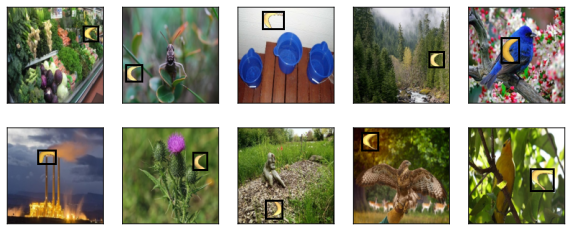

In [85]:
imgs = (batch[0][0:10].permute(0, 2, 3, 1))/255 # 希望是0~1
axes = d2l.show_images(imgs, 2, 5, scale=2)
for ax, label in zip(axes, batch[1][0:10]):
    d2l.show_bboxes(ax, [label[0][1:5] * edge_size], colors='k') 
#前面除以了edge_size256 这里又乘回来

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

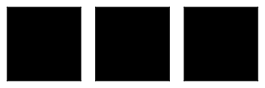

In [87]:

d2l.show_images(torch.zeros(3,256,256,3,dtype=torch.int),1,3)  # 全是0是黑 全1是白

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

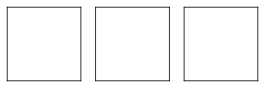

In [89]:
d2l.show_images(torch.ones(3,256,256,3),1,3)  # 全是0是黑 全1是白

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

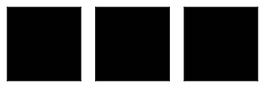

In [91]:
d2l.show_images(torch.ones(3,256,256,3,dtype=torch.int),1,3)  # 全是0是黑 全1是白

# 图片是float型，所以要转成【0，1】才能plt.imshow()生成图像.int类型就是0~255才显示

## 锚框

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

torch.set_printoptions(2)  # 精简输出精度

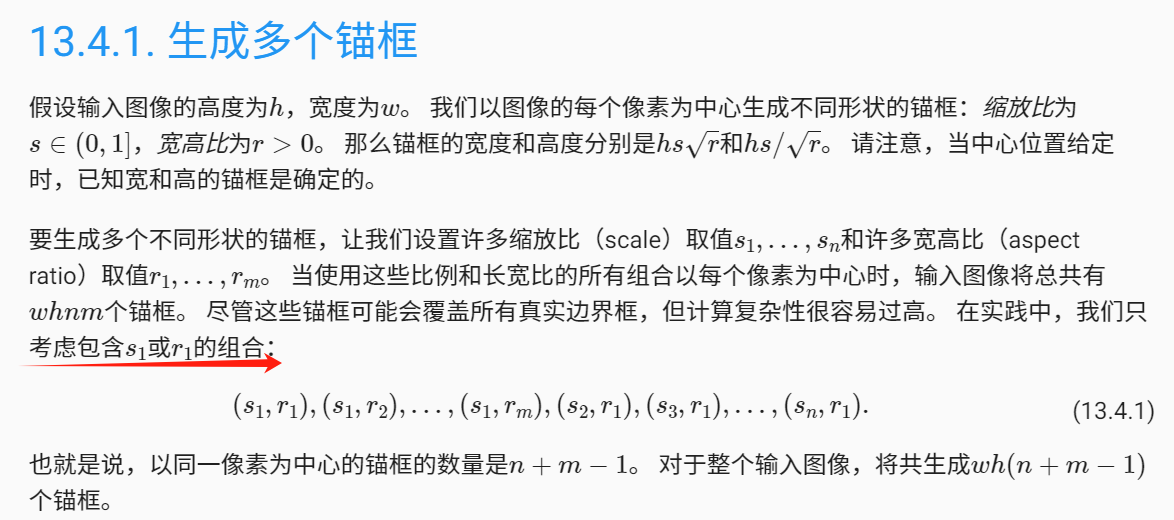

宽度的定义有错 应该是ws根号r

In [2]:
torch.rand(1,10).reshape(-1)

tensor([0.12, 0.05, 0.80, 0.48, 0.17, 0.28, 0.38, 0.48, 0.29, 0.20])

https://fkjkkll.github.io/2021/11/23/%E7%9B%AE%E6%A0%87%E6%A3%80%E6%B5%8BSSD/

建议阅读，这里说明了这里w和h为什么这么取。首先s不是特定的h变为s倍同时w变成s倍，而是面积变成s方，两种定义都没有长宽的s倍变化。同时沐神的代码的r应该是相比于原来宽高比变成r倍

In [5]:
#@save
def multibox_prior(data, sizes, ratios):
    global w,h,shift_y,shift_x
    """生成以每个像素为中心具有不同形状的锚框，最后返回每个点boxes_per_pixel个锚框的左上角和左右下角坐标"""
    in_height, in_width = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = (num_sizes + num_ratios - 1) # 每个像素生成的锚框数
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)

    # 为了将锚点移动到像素的中心，需要设置偏移量。
    # 因为一个像素的高为1且宽为1，我们选择偏移我们的中心0.5
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height  # 在y轴上缩放步长
    steps_w = 1.0 / in_width  # 在x轴上缩放步长

    # 生成锚框的所有中心点
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij') 
    # in_width列center_h  in_height行center_w（如果是‘xy’就是in_width行center_h，in_height列center_w）
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)  # flatten（） ravel
 
    # 生成“boxes_per_pixel”个高和宽，
    # 之后用于创建锚框的四角坐标(xmin,xmax,ymin,ymax)
    # 这里由于后续还有乘以对应原图的w和h 所以是相对的概念,也就是把原图宽和高先除过去了
    # 注意沐神的r是原图宽高比的r倍而不是锚框的宽高比
    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]),  
                   sizes[0] * torch.sqrt(ratio_tensor[1:])))\
                   * in_height / in_width  # 处理矩形输入   
    # hs根号r/w,这里r/w是为了在乘以对应的w和h后,r变成变化后的锚框的宽高比（这个时候s不再成立）
    # 若不乘，则s成立 r是原图宽高比的r倍。乘以以后 s不成立，r变成锚框宽高比
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]),
                   sizes[0] / torch.sqrt(ratio_tensor[1:]))) # s/根号r
    # 除以2来获得半高和半宽
    anchor_manipulations = torch.stack((-w, -h, w, h)).T.repeat(
                                        in_height * in_width, 1) / 2

    # 每个中心点都将有“boxes_per_pixel”个锚框，
    # 所以生成含所有锚框中心的网格，重复了“boxes_per_pixel”次
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y],
                dim=1).repeat_interleave(boxes_per_pixel, dim=0)
    output = out_grid + anchor_manipulations
    return output.unsqueeze(0)

In [118]:
 torch.stack((-w, -h, w, h)).T

tensor([[-1.00, -0.50,  1.00,  0.50]])

In [119]:
torch.stack((-w, -h, w, h), dim=1)

tensor([[-1.00, -0.50,  1.00,  0.50]])

In [6]:
img = d2l.plt.imread('../data/img/catdog.jpg')
h, w = img.shape[:2]

print(h, w)
X = torch.rand(size=(1, 3, h, w))
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
Y.shape

561 728


torch.Size([1, 2042040, 4])

In [7]:
h

tensor([0.75, 0.50, 0.25, 0.53, 1.06])

In [8]:
w

tensor([0.58, 0.39, 0.19, 0.82, 0.41])

In [9]:
torch.stack((-w, -h, w, h))

tensor([[-0.58, -0.39, -0.19, -0.82, -0.41],
        [-0.75, -0.50, -0.25, -0.53, -1.06],
        [ 0.58,  0.39,  0.19,  0.82,  0.41],
        [ 0.75,  0.50,  0.25,  0.53,  1.06]])

In [10]:
torch.stack((-w, -h, w, h)).T

tensor([[-0.58, -0.75,  0.58,  0.75],
        [-0.39, -0.50,  0.39,  0.50],
        [-0.19, -0.25,  0.19,  0.25],
        [-0.82, -0.53,  0.82,  0.53],
        [-0.41, -1.06,  0.41,  1.06]])

In [12]:
torch.stack((-w, -h, w, h)).T.repeat(561 * 728, 1) / 2

tensor([[-0.29, -0.38,  0.29,  0.38],
        [-0.19, -0.25,  0.19,  0.25],
        [-0.10, -0.12,  0.10,  0.12],
        ...,
        [-0.10, -0.12,  0.10,  0.12],
        [-0.41, -0.27,  0.41,  0.27],
        [-0.20, -0.53,  0.20,  0.53]])

In [18]:
torch.arange(5).repeat(10,2)  # 就是行重复10遍 列重复2遍

tensor([[0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]])

In [26]:
shift_x, shift_x.shape

(tensor([6.87e-04, 2.06e-03, 3.43e-03,  ..., 9.97e-01, 9.98e-01, 9.99e-01]),
 torch.Size([408408]))

In [21]:
shift_y

tensor([8.91e-04, 8.91e-04, 8.91e-04,  ..., 9.99e-01, 9.99e-01, 9.99e-01])

In [24]:
torch.stack([shift_x, shift_y, shift_x, shift_y]),torch.stack([shift_x, shift_y, shift_x, shift_y]).shape

(tensor([[6.87e-04, 2.06e-03, 3.43e-03,  ..., 9.97e-01, 9.98e-01, 9.99e-01],
         [8.91e-04, 8.91e-04, 8.91e-04,  ..., 9.99e-01, 9.99e-01, 9.99e-01],
         [6.87e-04, 2.06e-03, 3.43e-03,  ..., 9.97e-01, 9.98e-01, 9.99e-01],
         [8.91e-04, 8.91e-04, 8.91e-04,  ..., 9.99e-01, 9.99e-01, 9.99e-01]]),
 torch.Size([4, 408408]))

In [25]:
torch.stack([shift_x, shift_y, shift_x, shift_y], dim=1),torch.stack([shift_x, shift_y, shift_x, shift_y], dim=1).shape

(tensor([[6.87e-04, 8.91e-04, 6.87e-04, 8.91e-04],
         [2.06e-03, 8.91e-04, 2.06e-03, 8.91e-04],
         [3.43e-03, 8.91e-04, 3.43e-03, 8.91e-04],
         ...,
         [9.97e-01, 9.99e-01, 9.97e-01, 9.99e-01],
         [9.98e-01, 9.99e-01, 9.98e-01, 9.99e-01],
         [9.99e-01, 9.99e-01, 9.99e-01, 9.99e-01]]),
 torch.Size([408408, 4]))

In [29]:
x1 = torch.tensor([[11, 21, 31], [21, 31, 41]], dtype=torch.int)
x2 = torch.tensor([[12, 22, 32], [22, 32, 42]])
inputs = [x1, x2]
inputs

[tensor([[11, 21, 31],
         [21, 31, 41]], dtype=torch.int32),
 tensor([[12, 22, 32],
         [22, 32, 42]])]

In [30]:
torch.cat(inputs, dim=0),torch.cat(inputs, dim=0).shape,torch.cat(inputs, dim=1),torch.cat(inputs, dim=1).shape

(tensor([[11, 21, 31],
         [21, 31, 41],
         [12, 22, 32],
         [22, 32, 42]]),
 torch.Size([4, 3]),
 tensor([[11, 21, 31, 12, 22, 32],
         [21, 31, 41, 22, 32, 42]]),
 torch.Size([2, 6]))

In [31]:
torch.cat(inputs, dim=2)

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)

In [32]:
torch.stack(inputs, dim=2)

tensor([[[11, 12],
         [21, 22],
         [31, 32]],

        [[21, 22],
         [31, 32],
         [41, 42]]])

In [33]:
torch.stack(inputs, dim=3)

IndexError: Dimension out of range (expected to be in range of [-3, 2], but got 3)

https://blog.csdn.net/qq_40507857/article/details/119854085

stack函数的dim代表的是在第dim个维度上多出来一维度。具体可以看这个帖子.cat和stack本质是一样的，但是cat不升维，所以他的范围也比stack要小1

In [38]:
 torch.stack([shift_x, shift_y, shift_x, shift_y],
                dim=1)

tensor([[6.87e-04, 8.91e-04, 6.87e-04, 8.91e-04],
        [2.06e-03, 8.91e-04, 2.06e-03, 8.91e-04],
        [3.43e-03, 8.91e-04, 3.43e-03, 8.91e-04],
        ...,
        [9.97e-01, 9.99e-01, 9.97e-01, 9.99e-01],
        [9.98e-01, 9.99e-01, 9.98e-01, 9.99e-01],
        [9.99e-01, 9.99e-01, 9.99e-01, 9.99e-01]])

In [74]:
 torch.stack([shift_x, shift_y, shift_x, shift_y],
                dim=1).repeat_interleave(5, dim=0)  # x1y1 x1y1每行重复5遍（因为有5个框）  然后这个点是中心点  上下分别h/2 左右各w/2

tensor([[6.87e-04, 8.91e-04, 6.87e-04, 8.91e-04],
        [6.87e-04, 8.91e-04, 6.87e-04, 8.91e-04],
        [6.87e-04, 8.91e-04, 6.87e-04, 8.91e-04],
        ...,
        [9.99e-01, 9.99e-01, 9.99e-01, 9.99e-01],
        [9.99e-01, 9.99e-01, 9.99e-01, 9.99e-01],
        [9.99e-01, 9.99e-01, 9.99e-01, 9.99e-01]])

In [36]:
x1

tensor([[11, 21, 31],
        [21, 31, 41]], dtype=torch.int32)

In [41]:
x1.repeat(2,1) # repeat是看做一个整体  输入的是2,1是一个size

tensor([[11, 21, 31],
        [21, 31, 41],
        [11, 21, 31],
        [21, 31, 41]], dtype=torch.int32)

In [37]:
x1.repeat_interleave(9)  # repeat_interleave是一个个操作 第一个参数是重复遍数 第二参数是第几维度

tensor([11, 11, 11, 11, 11, 11, 11, 11, 11, 21, 21, 21, 21, 21, 21, 21, 21, 21,
        31, 31, 31, 31, 31, 31, 31, 31, 31, 21, 21, 21, 21, 21, 21, 21, 21, 21,
        31, 31, 31, 31, 31, 31, 31, 31, 31, 41, 41, 41, 41, 41, 41, 41, 41, 41],
       dtype=torch.int32)

In [45]:
x1.repeat_interleave(3,1) 

tensor([[11, 11, 11, 21, 21, 21, 31, 31, 31],
        [21, 21, 21, 31, 31, 31, 41, 41, 41]], dtype=torch.int32)

In [46]:
x1.repeat_interleave(3,0) 

tensor([[11, 21, 31],
        [11, 21, 31],
        [11, 21, 31],
        [21, 31, 41],
        [21, 31, 41],
        [21, 31, 41]], dtype=torch.int32)

In [47]:
x1.repeat_interleave(3,2) 

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)

In [53]:
w

tensor([0.58, 0.39, 0.19, 0.82, 0.41])

In [51]:
    anchor_manipulations = torch.stack((-w, -h, w, h)).T.repeat(
                                        561 * 728, 1) / 2

    # 每个中心点都将有“boxes_per_pixel”个锚框，
    # 所以生成含所有锚框中心的网格，重复了“boxes_per_pixel”次
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y],
                dim=1).repeat_interleave(5, dim=0)
    output = out_grid + anchor_manipulations
output


tensor([[-0.29, -0.37,  0.29,  0.38],
        [-0.19, -0.25,  0.19,  0.25],
        [-0.10, -0.12,  0.10,  0.13],
        ...,
        [ 0.90,  0.87,  1.10,  1.12],
        [ 0.59,  0.73,  1.41,  1.26],
        [ 0.79,  0.47,  1.20,  1.53]])

In [52]:
anchor_manipulations

tensor([[-0.29, -0.38,  0.29,  0.38],
        [-0.19, -0.25,  0.19,  0.25],
        [-0.10, -0.12,  0.10,  0.12],
        ...,
        [-0.10, -0.12,  0.10,  0.12],
        [-0.41, -0.27,  0.41,  0.27],
        [-0.20, -0.53,  0.20,  0.53]])

In [56]:
output.unsqueeze(0)

tensor([[[-0.29, -0.37,  0.29,  0.38],
         [-0.19, -0.25,  0.19,  0.25],
         [-0.10, -0.12,  0.10,  0.13],
         ...,
         [ 0.90,  0.87,  1.10,  1.12],
         [ 0.59,  0.73,  1.41,  1.26],
         [ 0.79,  0.47,  1.20,  1.53]]])

In [54]:
img = d2l.plt.imread('../data/img/catdog.jpg')
h1, w1 = img.shape[:2]

print(h, w)
X = torch.rand(size=(1, 3, h1, w1))
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
Y.shape

tensor([0.75, 0.50, 0.25, 0.53, 1.06]) tensor([0.58, 0.39, 0.19, 0.82, 0.41])


torch.Size([1, 2042040, 4])

In [57]:
Y

tensor([[[-0.29, -0.37,  0.29,  0.38],
         [-0.19, -0.25,  0.19,  0.25],
         [-0.10, -0.12,  0.10,  0.13],
         ...,
         [ 0.90,  0.87,  1.10,  1.12],
         [ 0.59,  0.73,  1.41,  1.26],
         [ 0.79,  0.47,  1.20,  1.53]]])

In [79]:
Y[0][0:100:5]

tensor([[-0.29, -0.37,  0.29,  0.38],
        [-0.29, -0.37,  0.29,  0.38],
        [-0.29, -0.37,  0.29,  0.38],
        [-0.28, -0.37,  0.29,  0.38],
        [-0.28, -0.37,  0.30,  0.38],
        [-0.28, -0.37,  0.30,  0.38],
        [-0.28, -0.37,  0.30,  0.38],
        [-0.28, -0.37,  0.30,  0.38],
        [-0.28, -0.37,  0.30,  0.38],
        [-0.28, -0.37,  0.30,  0.38],
        [-0.27, -0.37,  0.30,  0.38],
        [-0.27, -0.37,  0.30,  0.38],
        [-0.27, -0.37,  0.31,  0.38],
        [-0.27, -0.37,  0.31,  0.38],
        [-0.27, -0.37,  0.31,  0.38],
        [-0.27, -0.37,  0.31,  0.38],
        [-0.27, -0.37,  0.31,  0.38],
        [-0.26, -0.37,  0.31,  0.38],
        [-0.26, -0.37,  0.31,  0.38],
        [-0.26, -0.37,  0.32,  0.38]])

In [80]:
boxes.shape

torch.Size([561, 728, 5, 4])

In [73]:
boxes

tensor([[[[-0.29, -0.37,  0.29,  0.38],
          [-0.19, -0.25,  0.19,  0.25],
          [-0.10, -0.12,  0.10,  0.13],
          [-0.41, -0.26,  0.41,  0.27],
          [-0.20, -0.53,  0.21,  0.53]],

         [[-0.29, -0.37,  0.29,  0.38],
          [-0.19, -0.25,  0.19,  0.25],
          [-0.09, -0.12,  0.10,  0.13],
          [-0.41, -0.26,  0.41,  0.27],
          [-0.20, -0.53,  0.21,  0.53]],

         [[-0.29, -0.37,  0.29,  0.38],
          [-0.19, -0.25,  0.20,  0.25],
          [-0.09, -0.12,  0.10,  0.13],
          [-0.41, -0.26,  0.41,  0.27],
          [-0.20, -0.53,  0.21,  0.53]],

         ...,

         [[ 0.71, -0.37,  1.29,  0.38],
          [ 0.80, -0.25,  1.19,  0.25],
          [ 0.90, -0.12,  1.09,  0.13],
          [ 0.59, -0.26,  1.41,  0.27],
          [ 0.79, -0.53,  1.20,  0.53]],

         [[ 0.71, -0.37,  1.29,  0.38],
          [ 0.81, -0.25,  1.19,  0.25],
          [ 0.90, -0.12,  1.09,  0.13],
          [ 0.59, -0.26,  1.41,  0.27],
          [ 0.79,

In [55]:
img.shape

(561, 728, 3)

In [59]:
boxes = Y.reshape(h1, w1, 5, 4)  # 5代表5个框,4代表高宽
boxes[250, 250, 0, :] # 以（250,250）为中心的第一个锚框

tensor([0.06, 0.07, 0.63, 0.82])

In [71]:
#@save
def show_bboxes(axes, bboxes, labels=None, colors=None):
    """显示所有边界框"""
    def _make_list(obj, default_values=None):
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    labels = _make_list(labels)
    colors = _make_list(colors, ['b', 'g', 'r', 'm', 'c'])
    for i, bbox in enumerate(bboxes):
        color = colors[i % len(colors)]
        rect = d2l.bbox_to_rect(bbox.detach().numpy(), color)
        axes.add_patch(rect)
        if labels and len(labels) > i:
            text_color = 'k' if color == 'w' else 'w'
            axes.text(rect.xy[0], rect.xy[1], labels[i],
                      va='center', ha='center', fontsize=9, color=text_color,
                      bbox=dict(facecolor=color, lw=0))

In [61]:
[boxes[250, 250, 0, :]]

[tensor([0.06, 0.07, 0.63, 0.82])]

In [64]:
boxes[250, 250, 0, :].detach()

tensor([0.06, 0.07, 0.63, 0.82])

In [65]:
boxes[250, 250, 0, :].detach().numpy()

array([0.05511677, 0.07152405, 0.63307005, 0.821524  ], dtype=float32)

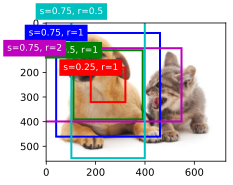

In [72]:
# d2l.set_figsize()
bbox_scale = torch.tensor((w1, h1, w1, h1))
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, boxes[250, 250, :, :] * bbox_scale,
            ['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2',
             's=0.75, r=0.5'])

In [81]:
bbox_scale

tensor([728, 561, 728, 561])

In [83]:
boxes[1, 1, :, :]

tensor([[-0.29, -0.37,  0.29,  0.38],
        [-0.19, -0.25,  0.19,  0.25],
        [-0.09, -0.12,  0.10,  0.13],
        [-0.41, -0.26,  0.41,  0.27],
        [-0.20, -0.53,  0.21,  0.53]])

In [93]:
bbox_ = (boxes[1, 1, :, :] * bbox_scale)[0]
bbox_ # 注意 这里是有负数的 有小数的！！！

tensor([-208.87, -208.88,  211.88,  211.88])

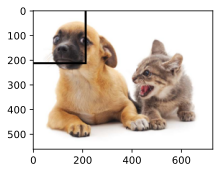

In [91]:
fig = d2l.plt.imshow(img)
rect_ = d2l.plt.Rectangle(
        xy=(bbox_[0], bbox_[1]), width=bbox_[2]-bbox_[0], height=bbox_[3]-bbox_[1],
        fill=False, linewidth=2)

fig.axes.add_patch(rect_)

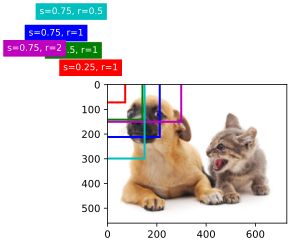

In [84]:
# d2l.set_figsize()
bbox_scale = torch.tensor((w1, h1, w1, h1))
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, boxes[1, 1, :, :] * bbox_scale,
            ['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2',
             's=0.75, r=0.5'])

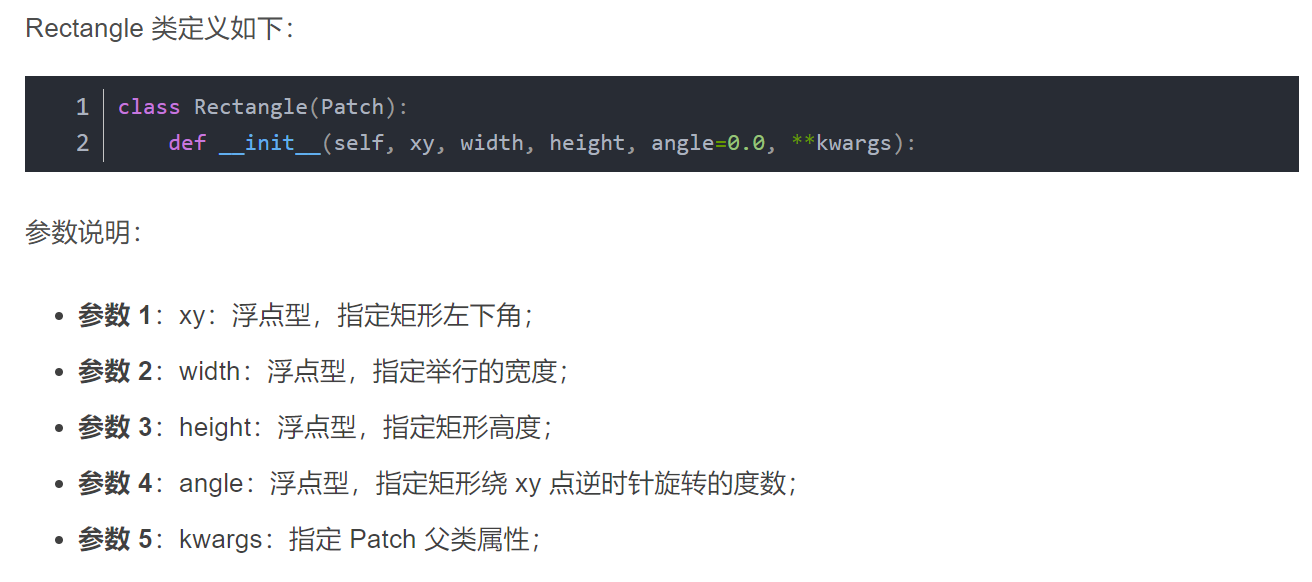
这里是连续的！！！ 且有负数（可以去一二三象限）

In [203]:
#@save
def mymultibox_prior(data, sizes, ratios):
    # global w,h,shift_y,shift_x
    """生成以每个像素为中心具有不同形状的锚框，最后返回每个点boxes_per_pixel个锚框的左上角和左右下角坐标"""
    in_height, in_width = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = (num_sizes + num_ratios - 1) # 每个像素生成的锚框数
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)

    # 为了将锚点移动到像素的中心，需要设置偏移量。
    # 因为一个像素的高为1且宽为1，我们选择偏移我们的中心0.5
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height  # 在y轴上缩放步长
    steps_w = 1.0 / in_width  # 在x轴上缩放步长

    # 生成锚框的所有中心点
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij') 
    # in_width列center_h  in_height行center_w（如果是‘xy’就是in_width行center_h，in_height列center_w）
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)  # flatten（） ravel
 
    # 生成“boxes_per_pixel”个高和宽，
    # 之后用于创建锚框的四角坐标(xmin,xmax,ymin,ymax)

    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]), sizes[0] * torch.sqrt(ratio_tensor[1:])))\
                            * math.sqrt(in_height / in_width)
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]), sizes[0] / torch.sqrt(ratio_tensor[1:])))\
                            * math.sqrt(in_width / in_height)
    # 除以2来获得半高和半宽
    anchor_manipulations = torch.stack((-w, -h, w, h)).T.repeat(
                                        in_height * in_width, 1) / 2

    # 每个中心点都将有“boxes_per_pixel”个锚框，
    # 所以生成含所有锚框中心的网格，重复了“boxes_per_pixel”次
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y],
                dim=1).repeat_interleave(boxes_per_pixel, dim=0)
    output = out_grid + anchor_manipulations
    return output.unsqueeze(0)

In [96]:
img = d2l.plt.imread('../data/img/catdog.jpg')
h1, w1 = img.shape[:2]

print(h, w)
X = torch.rand(size=(1, 3, h1, w1))
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
Y.shape

tensor([0.75, 0.50, 0.25, 0.53, 1.06]) tensor([0.58, 0.39, 0.19, 0.82, 0.41])


torch.Size([1, 2042040, 4])

In [97]:
boxes = Y.reshape(h1, w1, 5, 4)  # 5代表5个框,4代表高宽
boxes[250, 250, 0, :] # 以（250,250）为中心的第一个锚框

tensor([0.06, 0.07, 0.63, 0.82])

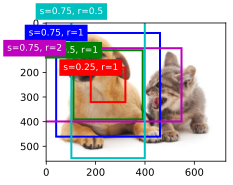

In [98]:
bbox_scale = torch.tensor((w1, h1, w1, h1))
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, boxes[250, 250, :, :] * bbox_scale,
            ['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2',
             's=0.75, r=0.5'])

In [100]:
import math

In [102]:
boxes_[250, 250, 0, :]

tensor([0.01, 0.02, 0.67, 0.87])

tensor([0.75, 0.50, 0.25, 0.53, 1.06]) tensor([0.58, 0.39, 0.19, 0.82, 0.41])


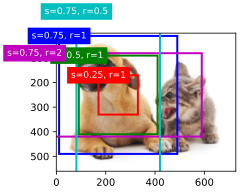

In [101]:
img = d2l.plt.imread('../data/img/catdog.jpg')
h1, w1 = img.shape[:2]

print(h, w)
X = torch.rand(size=(1, 3, h1, w1))
Y = mymultibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
Y.shape
boxes_ = Y.reshape(h1, w1, 5, 4)  # 5代表5个框,4代表高宽
boxes_[250, 250, 0, :] # 以（250,250）为中心的第一个锚框
bbox_scale = torch.tensor((w1, h1, w1, h1))
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, boxes_[250, 250, :, :] * bbox_scale,
            ['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2',
             's=0.75, r=0.5'])

In [110]:
fmap=torch.rand(1,10,1,1)
anchors = multibox_prior(fmap,[0.5],[1])
anchors,anchors[0],anchors[0][0] # 该点为正中心

(tensor([[[0.25, 0.25, 0.75, 0.75]]]),
 tensor([[0.25, 0.25, 0.75, 0.75]]),
 tensor([0.25, 0.25, 0.75, 0.75]))

In [106]:
bbox_scale = torch.tensor((w1, h1, w1, h1))
bbox_scale


tensor([728, 561, 728, 561])

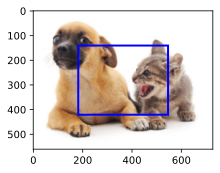

In [108]:
d2l.show_bboxes(d2l.plt.imshow(img).axes,anchors[0]*bbox_scale)

In [111]:
anchors[0]*bbox_scale

tensor([[182.00, 140.25, 546.00, 420.75]])

In [112]:
anchors[0][0]*bbox_scale

tensor([182.00, 140.25, 546.00, 420.75])

In [113]:
anchors*bbox_scale  # 可以相乘 维度为维度最大的张量的维度

tensor([[[182.00, 140.25, 546.00, 420.75]]])

In [114]:
fmap=torch.rand(1,10,2,2)
anchors = multibox_prior(fmap,[0.5],[1])
anchors,anchors[0],anchors[0][0] # 四个中心分别是图像四等分以后的四个中心

(tensor([[[0.00, 0.00, 0.50, 0.50],
          [0.50, 0.00, 1.00, 0.50],
          [0.00, 0.50, 0.50, 1.00],
          [0.50, 0.50, 1.00, 1.00]]]),
 tensor([[0.00, 0.00, 0.50, 0.50],
         [0.50, 0.00, 1.00, 0.50],
         [0.00, 0.50, 0.50, 1.00],
         [0.50, 0.50, 1.00, 1.00]]),
 tensor([0.00, 0.00, 0.50, 0.50]))

In [115]:
fmap=torch.rand(1,10,2,1)
anchors = multibox_prior(fmap,[0.5],[1])
anchors,anchors[0],anchors[0][0]  # 中心中等分竖线的两个四等分点

(tensor([[[0.00, 0.00, 1.00, 0.50],
          [0.00, 0.50, 1.00, 1.00]]]),
 tensor([[0.00, 0.00, 1.00, 0.50],
         [0.00, 0.50, 1.00, 1.00]]),
 tensor([0.00, 0.00, 1.00, 0.50]))

In [120]:
fmap=torch.rand(1,10,1,1)
anchors = mymultibox_prior(fmap,[0.5],[1])
anchors,anchors[0],anchors[0][0] # 该点为正中心

(tensor([[[0.25, 0.25, 0.75, 0.75]]]),
 tensor([[0.25, 0.25, 0.75, 0.75]]),
 tensor([0.25, 0.25, 0.75, 0.75]))

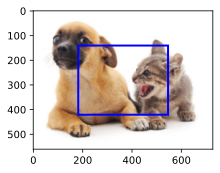

In [121]:
d2l.show_bboxes(d2l.plt.imshow(img).axes,anchors[0]*bbox_scale)

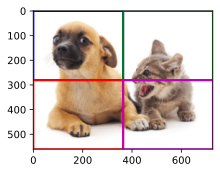

In [122]:
fmap=torch.rand(1,10,2,2)
anchors = mymultibox_prior(fmap,[0.5],[1])
anchors,anchors[0],anchors[0][0] # 该点为正中心
d2l.show_bboxes(d2l.plt.imshow(img).axes,anchors[0]*bbox_scale)

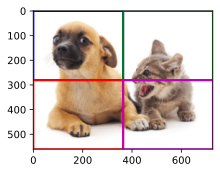

In [178]:
fmap=torch.rand(1,10,2,2)
anchors = multibox_prior(fmap,[0.5],[1])
anchors,anchors[0],anchors[0][0] # 该点为正中心
d2l.show_bboxes(d2l.plt.imshow(img).axes,anchors[0]*bbox_scale)

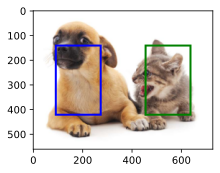

In [190]:
fmap=torch.rand(1,10,1,2)
anchors = multibox_prior(fmap,[0.5],[1])
anchors,anchors[0],anchors[0][0] # 该点为正中心
d2l.show_bboxes(d2l.plt.imshow(img).axes,anchors[0]*bbox_scale)

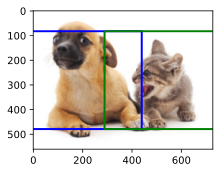

In [189]:
fmap=torch.rand(1,10,1,2)
anchors = mymultibox_prior(fmap,[0.5],[1])
anchors,anchors[0],anchors[0][0] # 该点为正中心
d2l.show_bboxes(d2l.plt.imshow(img).axes,anchors[0]*bbox_scale)

In [180]:
bbox_scale

tensor([728, 561, 728, 561])

In [209]:
img = d2l.plt.imread('../data/img/catdog.jpg')
h1, w1 = img.shape[:2]

print(h1, w1)
X = torch.rand(size=(1, 3, h1, w1))
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
Y.shape

561 728


torch.Size([1, 2042040, 4])

In [193]:
h

tensor([0.75, 0.50, 0.25, 0.53, 1.06])

In [210]:
boxes = Y.reshape(561, 728, 5, 4)
boxes[250, 250, 0, :]

tensor([0.06, 0.07, 0.63, 0.82])

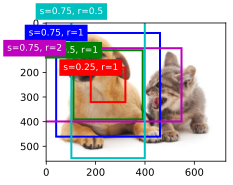

In [211]:
d2l.set_figsize()
bbox_scale = torch.tensor((w1, h1, w1, h1))
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, boxes[250, 250, :, :] * bbox_scale,
            ['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2',
             's=0.75, r=0.5'])

In [212]:
 boxes[250, 250, :, :] 

tensor([[ 0.06,  0.07,  0.63,  0.82],
        [ 0.15,  0.20,  0.54,  0.70],
        [ 0.25,  0.32,  0.44,  0.57],
        [-0.06,  0.18,  0.75,  0.71],
        [ 0.14, -0.08,  0.55,  0.98]])

In [216]:
[((0.63-0.06)*(0.82-0.07),0.75*0.75),((0.54-0.15)*(0.7-0.2),0.5*0.5)] # 面积是s方不成立！

[(0.42750000000000005, 0.5625), (0.19499999999999998, 0.25)]

In [222]:
(0.63-0.06)*728,0.75*531

(414.96000000000004, 398.25)

In [223]:
(0.54-0.15)*728,0.5*531

(283.92, 265.5)

In [204]:
img = d2l.plt.imread('../data/img/catdog.jpg')
h1, w1 = img.shape[:2]

print(h1, w1)
X = torch.rand(size=(1, 3, h1, w1))
Y = mymultibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1, 2, 0.5])
Y.shape

561 728


torch.Size([1, 2042040, 4])

In [205]:
boxes = Y.reshape(561, 728, 5, 4)
boxes[250, 250, 0, :]

tensor([0.01, 0.02, 0.67, 0.87])

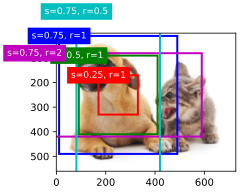

In [206]:
d2l.set_figsize()
bbox_scale = torch.tensor((w1, h1, w1, h1))
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, boxes[250, 250, :, :] * bbox_scale,
            ['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2',
             's=0.75, r=0.5'])

In [207]:
boxes[250, 250, :, :]

tensor([[ 0.01,  0.02,  0.67,  0.87],
        [ 0.12,  0.16,  0.56,  0.73],
        [ 0.23,  0.30,  0.45,  0.59],
        [-0.12,  0.14,  0.81,  0.75],
        [ 0.11, -0.16,  0.58,  1.05]])

In [217]:
[((0.67-0.01)*(0.87-0.02),0.75*0.75),((0.56-0.12)*(0.73-0.16),0.5*0.5)] # 面积是s方成立！

[(0.561, 0.5625), (0.2508, 0.25)]

In [218]:
img.shape

(561, 728, 3)

In [220]:
(0.67-0.01)*728,(0.87-0.02)*561

(480.48, 476.84999999999997)

In [221]:
(0.56-0.12)*728, (0.73-0.16)*561   # r也是满足的

(320.32000000000005, 319.77)

In [243]:
boxes.shape

torch.Size([561, 728, 5, 4])

In [246]:
boxes[:,2]

tensor([[[-0.29, -0.37,  0.29,  0.38],
         [-0.19, -0.25,  0.20,  0.25],
         [-0.09, -0.12,  0.10,  0.13],
         [-0.41, -0.26,  0.41,  0.27],
         [-0.20, -0.53,  0.21,  0.53]],

        [[-0.29, -0.37,  0.29,  0.38],
         [-0.19, -0.25,  0.20,  0.25],
         [-0.09, -0.12,  0.10,  0.13],
         [-0.41, -0.26,  0.41,  0.27],
         [-0.20, -0.53,  0.21,  0.53]],

        [[-0.29, -0.37,  0.29,  0.38],
         [-0.19, -0.25,  0.20,  0.25],
         [-0.09, -0.12,  0.10,  0.13],
         [-0.41, -0.26,  0.41,  0.27],
         [-0.20, -0.53,  0.21,  0.53]],

        ...,

        [[-0.29,  0.62,  0.29,  1.37],
         [-0.19,  0.75,  0.20,  1.25],
         [-0.09,  0.87,  0.10,  1.12],
         [-0.41,  0.73,  0.41,  1.26],
         [-0.20,  0.47,  0.21,  1.53]],

        [[-0.29,  0.62,  0.29,  1.37],
         [-0.19,  0.75,  0.20,  1.25],
         [-0.09,  0.87,  0.10,  1.12],
         [-0.41,  0.73,  0.41,  1.26],
         [-0.20,  0.47,  0.21,  1.53]],

 

In [224]:
#@save
def box_iou(boxes1, boxes2):
    """计算两个锚框或边界框列表中成对的交并比"""
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) *
                              (boxes[:, 3] - boxes[:, 1]))  # 单个像素的各个框的长宽进行计算
    # boxes1,boxes2,areas1,areas2的形状:
    # boxes1：(boxes1的数量,4),
    # boxes2：(boxes2的数量,4),
    # areas1：(boxes1的数量,),
    # areas2：(boxes2的数量,)
    areas1 = box_area(boxes1)
    areas2 = box_area(boxes2)
    # inter_upperlefts,inter_lowerrights,inters的形状:
    # (boxes1的数量,boxes2的数量,2)
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    # boxes1[:, None, :2] 这个表达式的作用是将 boxes1 这个二维张量
    # （假设其形状为 [N, 4]，其中 N 是边界框的数量）扩展为三维张量。扩展后的形状变为 [N, 1, 2]，其中 1 是新增加的维度。
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)  # 没有交集的时候会有负数存在 弄到0
    # inter_areasandunion_areas的形状:(boxes1的数量,boxes2的数量)  # 每个数是两者的交集面积/并集面积
    inter_areas = inters[:, :, 0] * inters[:, :, 1]
    union_areas = areas1[:, None] + areas2 - inter_areas # 生一维度利用广播机制 计算每个框之间的并集
    return inter_areas / union_areas

'''由于 boxes1[:, None, :2] 的形状是 [N, 1, 2]，而 boxes2[:, :2] 的形状是 [M, 2]，
这个torch.max操作会利用广播机制，将 boxes1 中的每个边界框的左上角坐标与 boxes2 中的每个边界框
的左上角坐标进行比较。结果是一个形状为 [N, M, 2] 的三维张量，其中每个元素
表示 boxes1 中的一个边界框与 boxes2 中的一个边界框的交集的左上角坐标。'''

In [256]:
tensor = torch.tensor([-3, -1, 0, 2, 5])

# 使用clamp将所有值限制在0到4之间
clamped_tensor = torch.clamp(tensor, min=0, max=4)

print(clamped_tensor)  # 输出: tensor([0, 0, 0, 2, 4])

tensor([0, 0, 0, 2, 4])


In [257]:
boxes[250, 250, :, :][:,2]

tensor([0.63, 0.54, 0.44, 0.75, 0.55])

In [247]:
boxes[250, 250, :, :]

tensor([[ 0.06,  0.07,  0.63,  0.82],
        [ 0.15,  0.20,  0.54,  0.70],
        [ 0.25,  0.32,  0.44,  0.57],
        [-0.06,  0.18,  0.75,  0.71],
        [ 0.14, -0.08,  0.55,  0.98]])

In [251]:
boxes[250, 250, :, :][:,:2]

tensor([[ 0.06,  0.07],
        [ 0.15,  0.20],
        [ 0.25,  0.32],
        [-0.06,  0.18],
        [ 0.14, -0.08]])

In [249]:
boxes[250, 250, :, :][:,None,:2]

tensor([[[ 0.06,  0.07]],

        [[ 0.15,  0.20]],

        [[ 0.25,  0.32]],

        [[-0.06,  0.18]],

        [[ 0.14, -0.08]]])

In [254]:
torch.max(boxes[250, 250, :, :][:,None,:2],boxes[250, 250, :, :][:,:2]) # 对应位置比较大小 若维度不一样会触发广播机制！


tensor([[[ 0.06,  0.07],
         [ 0.15,  0.20],
         [ 0.25,  0.32],
         [ 0.06,  0.18],
         [ 0.14,  0.07]],

        [[ 0.15,  0.20],
         [ 0.15,  0.20],
         [ 0.25,  0.32],
         [ 0.15,  0.20],
         [ 0.15,  0.20]],

        [[ 0.25,  0.32],
         [ 0.25,  0.32],
         [ 0.25,  0.32],
         [ 0.25,  0.32],
         [ 0.25,  0.32]],

        [[ 0.06,  0.18],
         [ 0.15,  0.20],
         [ 0.25,  0.32],
         [-0.06,  0.18],
         [ 0.14,  0.18]],

        [[ 0.14,  0.07],
         [ 0.15,  0.20],
         [ 0.25,  0.32],
         [ 0.14,  0.18],
         [ 0.14, -0.08]]])

In [255]:
torch.max(boxes[250, 250, :, :][:,None,:2],boxes[250, 250, :, :][:,None,:2])

tensor([[[ 0.06,  0.07]],

        [[ 0.15,  0.20]],

        [[ 0.25,  0.32]],

        [[-0.06,  0.18]],

        [[ 0.14, -0.08]]])

In [262]:
torch.full((2),-1)

TypeError: full(): argument 'size' (position 1) must be tuple of ints, not int

In [263]:
torch.full((2,),-1)

tensor([-1, -1])

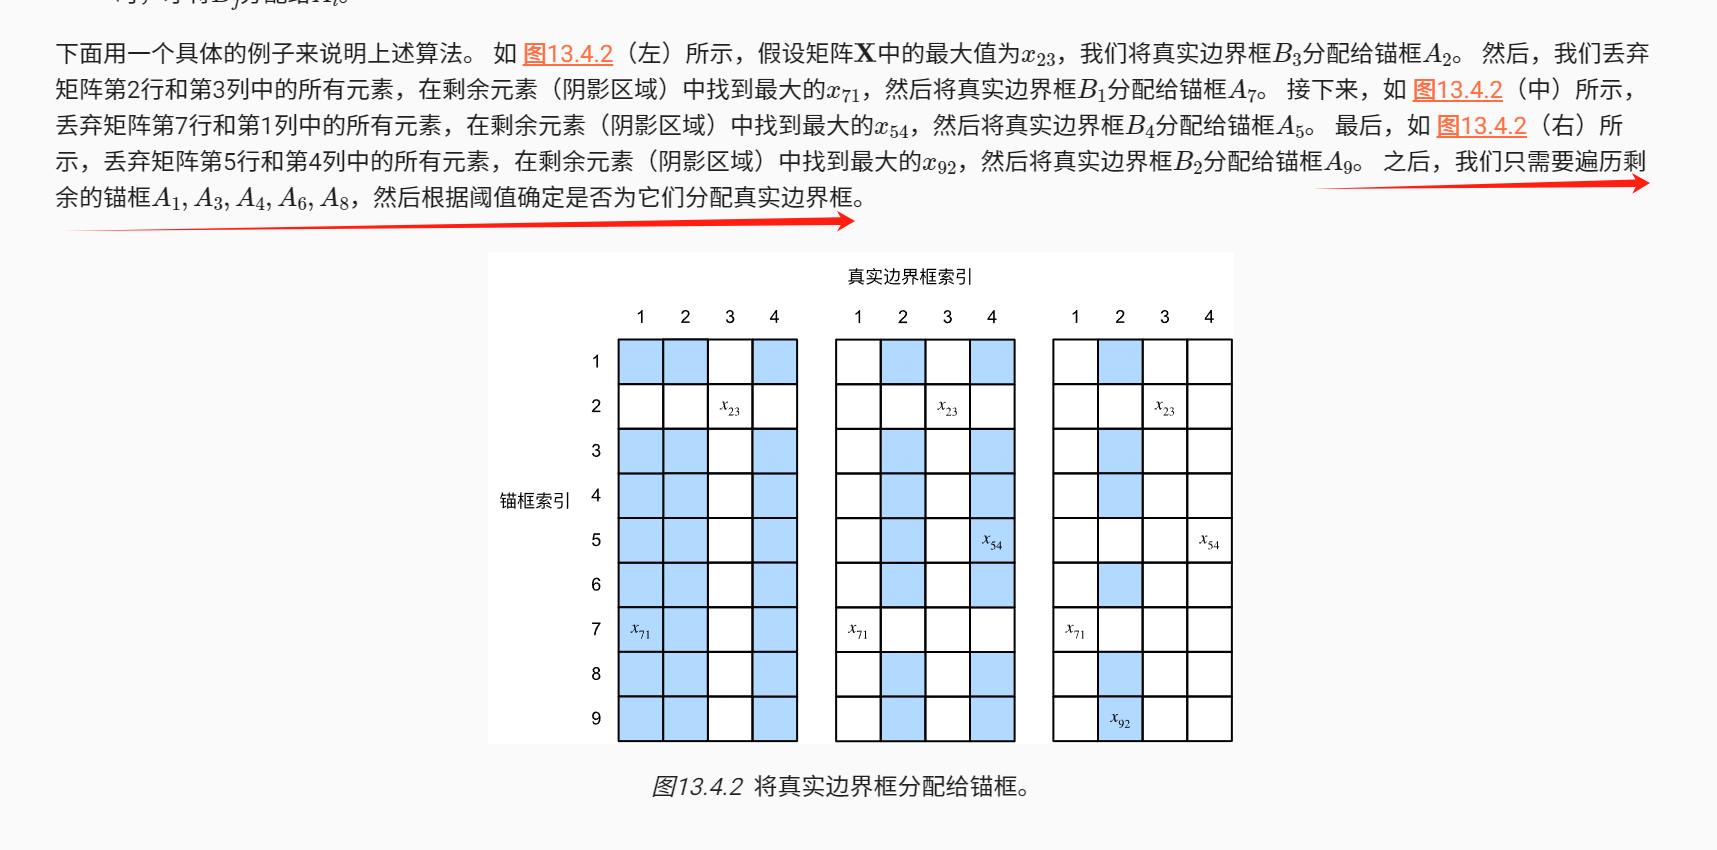
这个解释挺好的 就是先把真实值给分配好锚框 然后再弄剩下锚框的真实值（这个时候变成-1的又变回原值，所以代码里先这部再划线 后续划线的时候会覆盖的 所以可以认为是划线先的）

In [225]:
#@save
def assign_anchor_to_bbox(ground_truth, anchors, device, iou_threshold=0.5):
    """将最接近的真实边界框分配给锚框"""
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]
    # 位于第i行和第j列的元素x_ij是锚框i和真实边界框j的IoU
    jaccard = box_iou(anchors, ground_truth)  # 一个二维矩阵 每个值代表锚框和真实值的交并比
    # 对于每个锚框，分配的真实边界框的张量
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long,
                                  device=device) # num_anchors的一维向量 初始化为-1 
    # 根据阈值，决定是否分配真实边界框
    max_ious, indices = torch.max(jaccard, dim=1) # 找每个锚框的最大交并比的真实值以及它的坐标
    anc_i = torch.nonzero(max_ious >= iou_threshold).reshape(-1) # 选出超过阈值的坐标
    box_j = indices[max_ious >= iou_threshold] # 超过阈值的索引（是和哪个真实值的交并比超过了阈值）
    anchors_bbox_map[anc_i] = box_j # 第anc_i个锚框满足了阈值 它的最近真实值是box_j
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    for _ in range(num_gt_boxes):
        max_idx = torch.argmax(jaccard)
        box_idx = (max_idx % num_gt_boxes).long() # 列索引
        anc_idx = (max_idx / num_gt_boxes).long() # 行索引
        anchors_bbox_map[anc_idx] = box_idx
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx, :] = row_discard
        # 这行代码将当前处理的真实边界框（列）的所有IoU值设置为一个特定的丢弃值（col_discard），
    # 通常是 -1 或其他标记值。这样做的目的是标记这个真实边界框已经被分配，以防止它被再次分配给其他锚框。
    return anchors_bbox_map
'''
循环的目的是为了处理那些IoU值小于阈值的情况，确保每个真实边界框至少被一个锚框“覆盖”，即使这个锚框不是最佳匹配。
这个过程会更新 anchors_bbox_map，将每个真实边界框分配给与其IoU最大的锚框，不管这个IoU值是否超过了阈值。
这样可以确保所有的真实边界框都被考虑到，即使它们没有高IoU的锚框匹配。
'''

In [273]:
torch.nonzero(torch.tensor([0.9, 0.7, 0.8, 0.6, 0.9])>0.5)

tensor([[0],
        [1],
        [2],
        [3],
        [4]])

In [266]:
torch.argmax(torch.arange(20).reshape(2,2,5))

tensor(19)

In [226]:
#@save
def offset_boxes(anchors, assigned_bb, eps=1e-6):
    """对锚框偏移量的转换"""
    c_anc = d2l.box_corner_to_center(anchors)
    c_assigned_bb = d2l.box_corner_to_center(assigned_bb)
    offset_xy = 10 * (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]
    offset_wh = 5 * torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])
    offset = torch.cat([offset_xy, offset_wh], axis=1)
    return offset

In [277]:
torch.arange(20).reshape(2,2,5).unsqueeze(0).shape

torch.Size([1, 2, 2, 5])

In [279]:
torch.arange(20).reshape(2,2,5).squeeze().shape
# 1. 如果指定的维度大于1，那么将操作无效

# 2. 如果不指定维度N，那么将删除所有维度为1的维度

torch.Size([2, 2, 5])

In [227]:
#@save
def multibox_target(anchors, labels):
    """使用真实边界框标记锚框"""
    batch_size, anchors = labels.shape[0], anchors.squeeze(0) # labels是五列的标签加x1y1 x2y2
    batch_offset, batch_mask, batch_class_labels = [], [], []
    device, num_anchors = anchors.device, anchors.shape[0]
    for i in range(batch_size):
        label = labels[i, :, :]
        anchors_bbox_map = assign_anchor_to_bbox(
            label[:, 1:], anchors, device)
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(
            1, 4)
        # 将类标签和分配的边界框坐标初始化为零
        class_labels = torch.zeros(num_anchors, dtype=torch.long,
                                   device=device)
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32,
                                  device=device)
        # 使用真实边界框来标记锚框的类别。
        # 如果一个锚框没有被分配，标记其为背景（值为零）
        indices_true = torch.nonzero(anchors_bbox_map >= 0)
        bb_idx = anchors_bbox_map[indices_true] # 行向量 数值是真实值的索引,个数为锚框数
        class_labels[indices_true] = label[bb_idx, 0].long() + 1 
        # 第0个数是标签所以＋1了,因为0被认为是没被处理，是背景。而对于类别来说 是有第0类的 所以要加1
        # 分类主要是assign_anchor_to_bbox函数做了 这里重新整理一下 因为多了一个背景类
        assigned_bb[indices_true] = label[bb_idx, 1:] # 左上右下坐标
        # 偏移量转换
        offset = offset_boxes(anchors, assigned_bb) * bbox_mask  # 背景就乘以0 不关注偏移度
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)
    bbox_offset = torch.stack(batch_offset)
    bbox_mask = torch.stack(batch_mask)
    class_labels = torch.stack(batch_class_labels)
    return (bbox_offset, bbox_mask, class_labels)

In [283]:
torch.arange(5,10)[[1,2,3]]

tensor([6, 7, 8])

In [288]:
torch.arange(5,10)[torch.arange(5,10)<9]

tensor([5, 6, 7, 8])

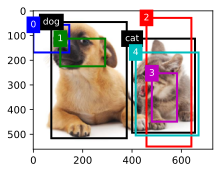

In [228]:
ground_truth = torch.tensor([[0, 0.1, 0.08, 0.52, 0.92],
                         [1, 0.55, 0.2, 0.9, 0.88]])
anchors = torch.tensor([[0, 0.1, 0.2, 0.3], [0.15, 0.2, 0.4, 0.4],
                    [0.63, 0.05, 0.88, 0.98], [0.66, 0.45, 0.8, 0.8],
                    [0.57, 0.3, 0.92, 0.9]])

fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, ground_truth[:, 1:] * bbox_scale, ['dog', 'cat'], 'k')
show_bboxes(fig.axes, anchors * bbox_scale, ['0', '1', '2', '3', '4']);

In [229]:
labels = multibox_target(anchors.unsqueeze(dim=0),
                         ground_truth.unsqueeze(dim=0))

In [230]:
labels[2] # 012分别是背景 狗 猫。索引代表是第几个框

tensor([[0, 1, 2, 0, 2]])

In [232]:
# 返回的第二个元素是掩码（mask）变量，形状为（批量大小，锚框数的四倍）。 
# 掩码变量中的元素与每个锚框的4个偏移量一一对应。 由于我们不关心对背景的检测，负类的偏移量不应影响目标函数。
# 通过元素乘法，掩码变量中的零将在计算目标函数之前过滤掉负类偏移量。

In [231]:
labels[1]

tensor([[0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1.,
         1., 1.]])

In [233]:
# 返回的第一个元素包含了为每个锚框标记的四个偏移值。 请注意，负类锚框的偏移量被标记为零。
labels[0]

tensor([[-0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00,  1.40e+00,  1.00e+01,
          2.59e+00,  7.18e+00, -1.20e+00,  2.69e-01,  1.68e+00, -1.57e+00,
         -0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00, -5.71e-01, -1.00e+00,
          4.17e-06,  6.26e-01]])

In [234]:
labels

(tensor([[-0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00,  1.40e+00,  1.00e+01,
           2.59e+00,  7.18e+00, -1.20e+00,  2.69e-01,  1.68e+00, -1.57e+00,
          -0.00e+00, -0.00e+00, -0.00e+00, -0.00e+00, -5.71e-01, -1.00e+00,
           4.17e-06,  6.26e-01]]),
 tensor([[0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1.,
          1., 1.]]),
 tensor([[0, 1, 2, 0, 2]]))

In [235]:
#@save
def offset_inverse(anchors, offset_preds):
    """根据带有预测偏移量的锚框来预测边界框"""
    anc = d2l.box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = torch.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]
    pred_bbox = torch.cat((pred_bbox_xy, pred_bbox_wh), axis=1)
    predicted_bbox = d2l.box_center_to_corner(pred_bbox)
    return predicted_bbox

In [236]:
#@save
def nms(boxes, scores, iou_threshold):
    """对预测边界框的置信度进行排序"""
    B = torch.argsort(scores, dim=-1, descending=True)
    keep = []  # 保留预测边界框的指标
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1: break
        iou = box_iou(boxes[i, :].reshape(-1, 4),
                      boxes[B[1:], :].reshape(-1, 4)).reshape(-1)
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        B = B[inds + 1]
    return torch.tensor(keep, device=boxes.device) 
# 注意这里求交并比都是和全体锚框求的,还有一种算法是每个类之内挑一个 都可以

In [237]:
#@save
def multibox_detection(cls_probs, offset_preds, anchors, nms_threshold=0.5,
                       pos_threshold=0.009999999):
    """使用非极大值抑制来预测边界框"""
    device, batch_size = cls_probs.device, cls_probs.shape[0]
    anchors = anchors.squeeze(0)
    num_classes, num_anchors = cls_probs.shape[1], cls_probs.shape[2]
    out = []
    for i in range(batch_size):
        cls_prob, offset_pred = cls_probs[i], offset_preds[i].reshape(-1, 4)
        conf, class_id = torch.max(cls_prob[1:], 0) # 第0行是背景的概率,求每列的最大值
        predicted_bb = offset_inverse(anchors, offset_pred)
        keep = nms(predicted_bb, conf, nms_threshold)

        # 找到所有的non_keep索引，并将类设置为背景
        all_idx = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep, all_idx))
        uniques, counts = combined.unique(return_counts=True)
        non_keep = uniques[counts == 1]
        all_id_sorted = torch.cat((keep, non_keep))
        class_id[non_keep] = -1 # 弄成背景
        class_id = class_id[all_id_sorted] # 重新排了一下序
        conf, predicted_bb = conf[all_id_sorted], predicted_bb[all_id_sorted]
        # pos_threshold是一个用于非背景预测的阈值
        below_min_idx = (conf < pos_threshold)
        class_id[below_min_idx] = -1
        conf[below_min_idx] = 1 - conf[below_min_idx] # 置信度变成1-原来的置信度
        pred_info = torch.cat((class_id.unsqueeze(1),
                               conf.unsqueeze(1),
                               predicted_bb), dim=1)
        out.append(pred_info)
    return torch.stack(out)

In [289]:
torch.cat((torch.arange(10),torch.arange(3)))

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2])

In [292]:
uniques,counts = torch.cat((torch.arange(10),torch.arange(3))).unique(return_counts = True)
uniques,counts

(tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 tensor([2, 2, 2, 1, 1, 1, 1, 1, 1, 1]))

In [238]:
anchors = torch.tensor([[0.1, 0.08, 0.52, 0.92], [0.08, 0.2, 0.56, 0.95],
                      [0.15, 0.3, 0.62, 0.91], [0.55, 0.2, 0.9, 0.88]])
offset_preds = torch.tensor([0] * anchors.numel())
cls_probs = torch.tensor([[0] * 4,  # 背景的预测概率
                      [0.9, 0.8, 0.7, 0.1],  # 狗的预测概率
                      [0.1, 0.2, 0.3, 0.9]])  # 猫的预测概率

In [294]:
anchors.numel()

16

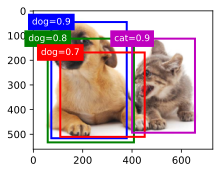

In [239]:
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, anchors * bbox_scale,
            ['dog=0.9', 'dog=0.8', 'dog=0.7', 'cat=0.9'])

In [240]:
output = multibox_detection(cls_probs.unsqueeze(dim=0),
                            offset_preds.unsqueeze(dim=0),
                            anchors.unsqueeze(dim=0),
                            nms_threshold=0.5)
output

tensor([[[ 0.00,  0.90,  0.10,  0.08,  0.52,  0.92],
         [ 1.00,  0.90,  0.55,  0.20,  0.90,  0.88],
         [-1.00,  0.80,  0.08,  0.20,  0.56,  0.95],
         [-1.00,  0.70,  0.15,  0.30,  0.62,  0.91]]])

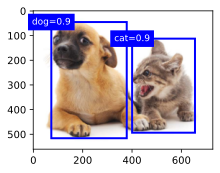

In [241]:
fig = d2l.plt.imshow(img)
for i in output[0].detach().numpy():
    if i[0] == -1:  # 背景就不画了
        continue
    label = ('dog=', 'cat=')[int(i[0])] + str(i[1])
    show_bboxes(fig.axes, [torch.tensor(i[2:]) * bbox_scale], label)

总结：1.如何生成锚框 2.如何判断锚框有效 3.每个类保留一个锚框进行预测

## 物体检测方法
### RCNN

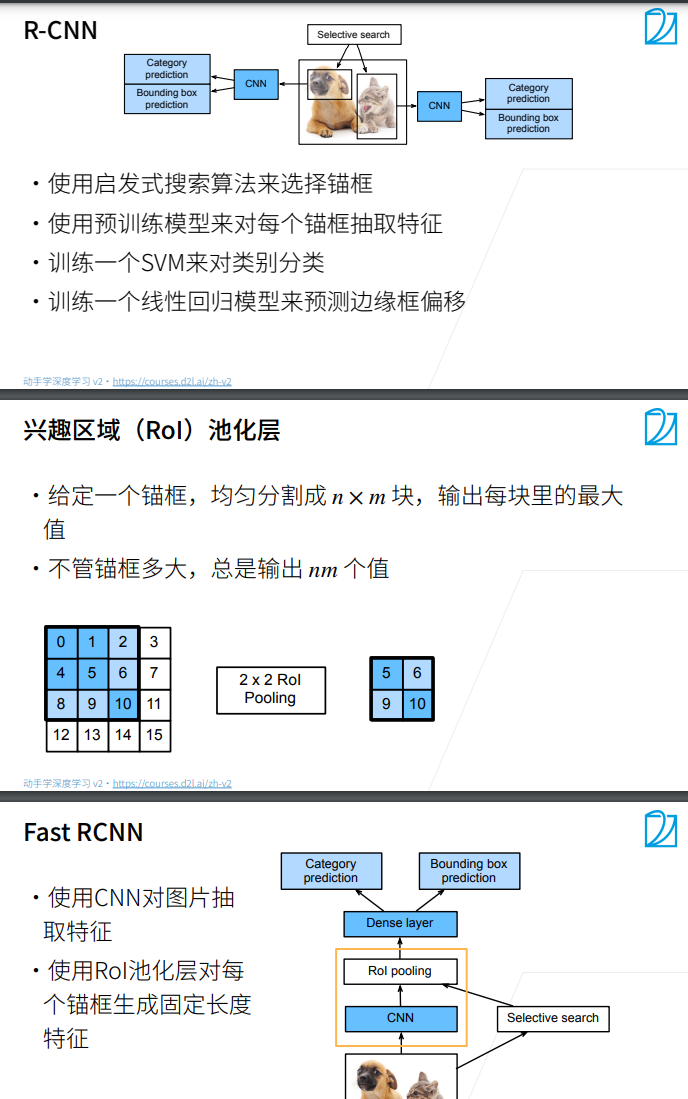
RCNN：
对输入图像使用选择性搜索来选取多个高质量的提议区域 (Uijlings et al., 2013)。这些提议区域通常是在多个尺度下选取的，并具有不同的形状和大小。每个提议区域都将被标注类别和真实边界框；

选择一个预训练的卷积神经网络，并将其在输出层之前截断。将每个提议区域变形为网络需要的输入尺寸，并通过前向传播输出抽取的提议区域特征；

将每个提议区域的特征连同其标注的类别作为一个样本。训练多个支持向量机对目标分类，其中每个支持向量机用来判断样本是否属于某一个类别；

将每个提议区域的特征连同其标注的边界框作为一个样本，训练线性回归模型来预测真实边界框。

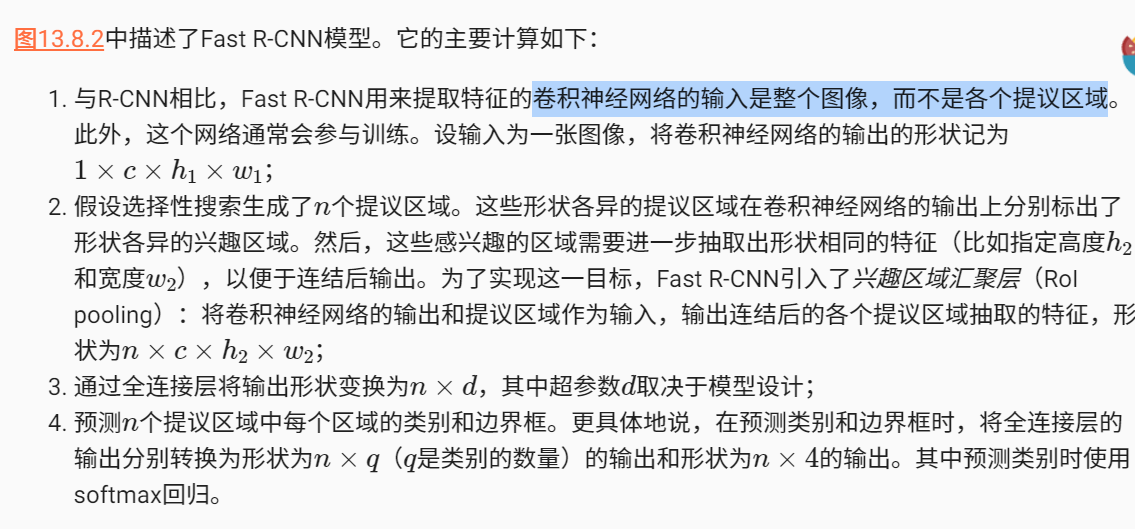


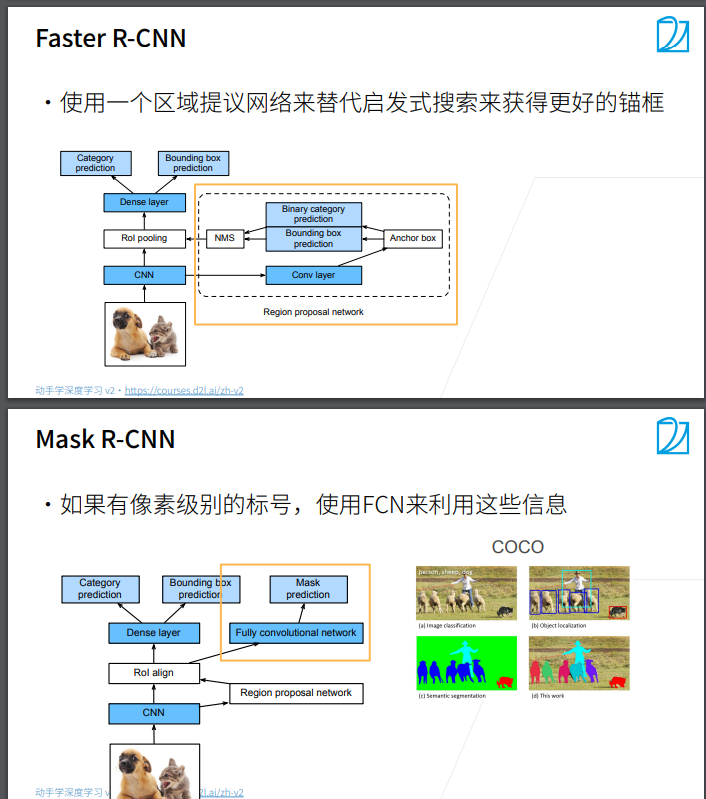
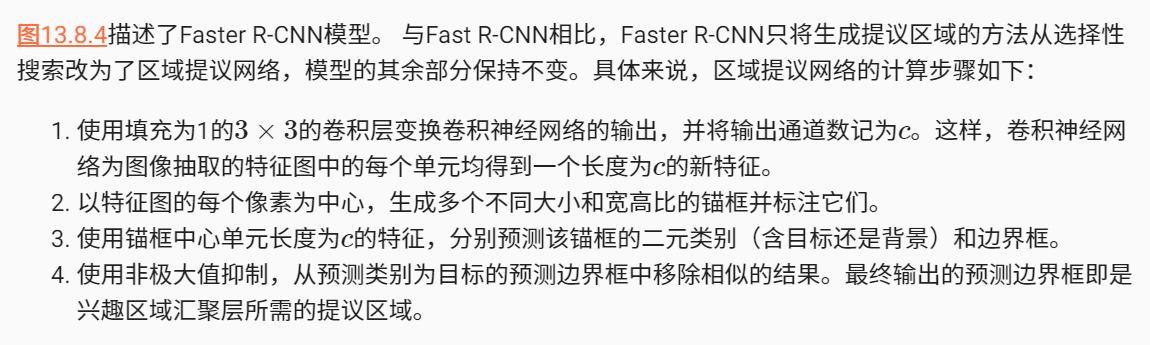
使用NMS减少锚框的总数


Mask R-CNN是基于Faster R-CNN修改而来的。 具体来说，Mask R-CNN将兴趣区域汇聚层替换为了 兴趣区域对齐层，使用双线性插值（bilinear interpolation）来保留特征图上的空间信息，从而更适于像素级预测。 兴趣区域对齐层的输出包含了所有与兴趣区域的形状相同的特征图。 它们不仅被用于预测每个兴趣区域的类别和边界框，还通过额外的全卷积网络预测目标的像素级位置。

### SSD
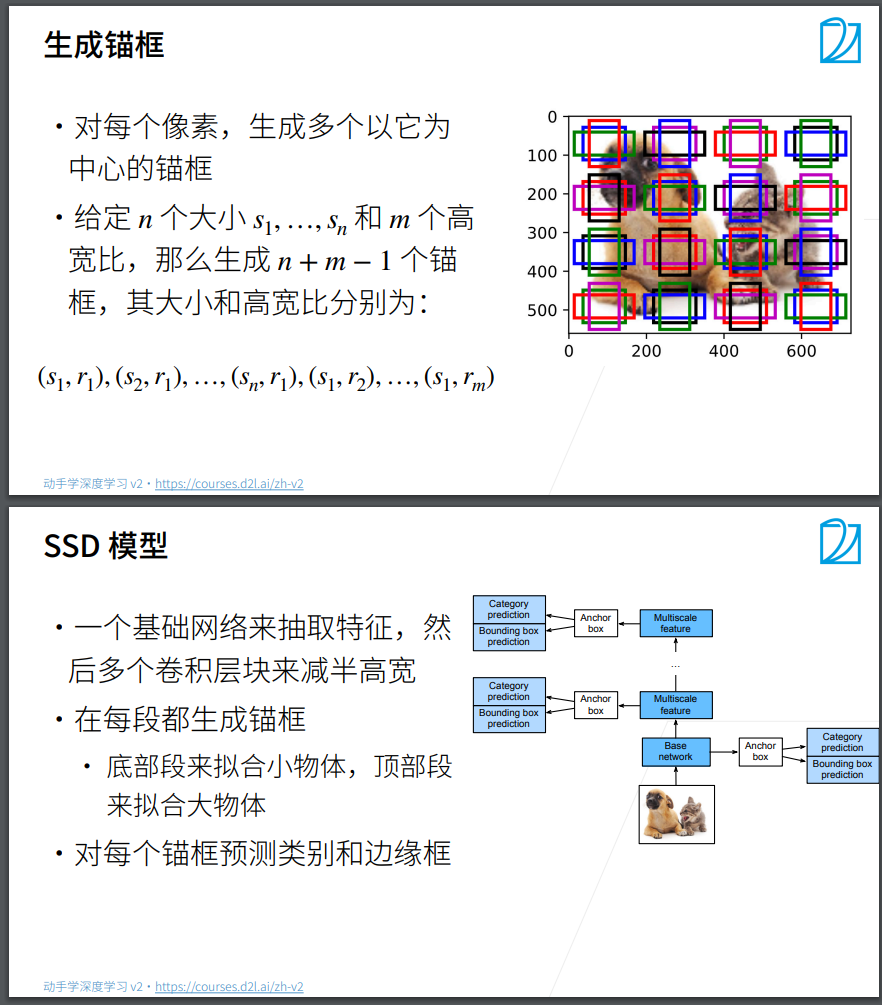

 由于接近顶部的多尺度特征图较小，但具有较大的感受野，它们适合检测较少但较大的物体。 简而言之，通过多尺度特征块，单发多框检测生成不同大小的锚框，并通过预测边界框的类别和偏移量来检测大小不同的目标，因此这是一个多尺度目标检测模型。

### yolo
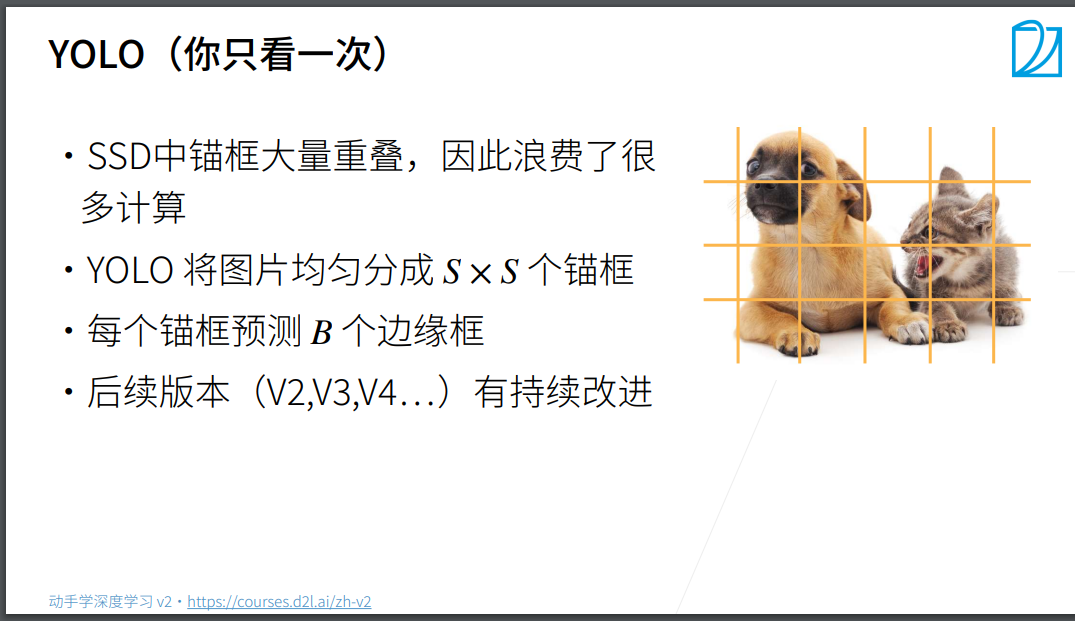
B个边缘框就是B个物体，因为有可能物体在交点上，所以多预测几个

In [295]:
import torch
from d2l import torch as d2l

img = d2l.plt.imread('../data/img/catdog.jpg')
h,w = img.shape[:2]
h,w

(561, 728)

In [296]:
def display_anchors(fmap_w, fmap_h, s):
    d2l.set_figsize()
    # 前两个维度上的值不影响输出
    fmap = torch.zeros((1, 10, fmap_h, fmap_w))
    anchors = d2l.multibox_prior(fmap, sizes=s, ratios=[1, 2, 0.5])
    bbox_scale = torch.tensor((w, h, w, h))
    d2l.show_bboxes(d2l.plt.imshow(img).axes,
                    anchors[0] * bbox_scale)

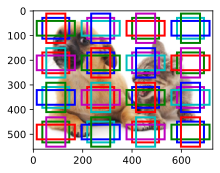

In [297]:
display_anchors(fmap_w=4, fmap_h=4, s=[0.15]) # 4*4一共有16个中心点

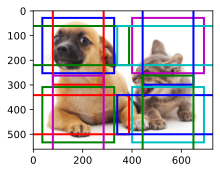

In [298]:
display_anchors(fmap_w=2, fmap_h=2, s=[0.4])  # s随着map变小而大 但是不能太大 不同像素点不建议有重合

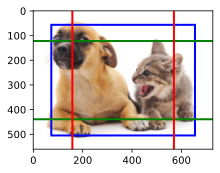

In [300]:
display_anchors(fmap_w=1, fmap_h=1, s=[0.8])  # map小的时候 可以用大的size 弄大的范围

### SSD的实现

In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

# 类别预测
def cls_predictor(num_inputs, num_anchors, num_classes):  # 输入的通道数 锚框数   种类数
    return nn.Conv2d(num_inputs, num_anchors * (num_classes + 1),    # 因为还有一个背景 所以加一
                     kernel_size=3, padding=1)  # NiN中的思想 用输出通道来预测类别 而不是全连接层

In [2]:
# 边界框预测  预测到真实锚框的偏移
def bbox_predictor(num_inputs, num_anchors):
    return nn.Conv2d(num_inputs, num_anchors * 4, kernel_size=3, padding=1)

In [3]:
def forward(x, block):
    return block(x)

Y1 = forward(torch.zeros((2, 8, 20, 20)), cls_predictor(8, 5, 10))
Y2 = forward(torch.zeros((2, 16, 10, 10)), cls_predictor(16, 3, 10))
Y1.shape, Y2.shape

(torch.Size([2, 55, 20, 20]), torch.Size([2, 33, 10, 10]))

In [11]:
def flatten_pred(pred):
    return torch.flatten(pred.permute(0, 2, 3, 1), start_dim=1)  # 通道数放到最后

def concat_preds(preds):
    return torch.cat([flatten_pred(p) for p in preds], dim=1)

In [12]:
a = torch.arange(40).reshape(1,2,4,5)
a

tensor([[[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9],
          [10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]],

         [[20, 21, 22, 23, 24],
          [25, 26, 27, 28, 29],
          [30, 31, 32, 33, 34],
          [35, 36, 37, 38, 39]]]])

In [13]:
a.permute(0, 2, 3, 1)

tensor([[[[ 0, 20],
          [ 1, 21],
          [ 2, 22],
          [ 3, 23],
          [ 4, 24]],

         [[ 5, 25],
          [ 6, 26],
          [ 7, 27],
          [ 8, 28],
          [ 9, 29]],

         [[10, 30],
          [11, 31],
          [12, 32],
          [13, 33],
          [14, 34]],

         [[15, 35],
          [16, 36],
          [17, 37],
          [18, 38],
          [19, 39]]]])

In [14]:
torch.flatten(a.permute(0, 2, 3, 1))   # 这样每个像素的预测是连续值

tensor([ 0, 20,  1, 21,  2, 22,  3, 23,  4, 24,  5, 25,  6, 26,  7, 27,  8, 28,
         9, 29, 10, 30, 11, 31, 12, 32, 13, 33, 14, 34, 15, 35, 16, 36, 17, 37,
        18, 38, 19, 39])

In [15]:
torch.flatten(a.permute(0, 2, 3, 1), start_dim=1)  # 第0维保持不变

tensor([[ 0, 20,  1, 21,  2, 22,  3, 23,  4, 24,  5, 25,  6, 26,  7, 27,  8, 28,
          9, 29, 10, 30, 11, 31, 12, 32, 13, 33, 14, 34, 15, 35, 16, 36, 17, 37,
         18, 38, 19, 39]])

In [16]:
concat_preds([Y1, Y2]).shape

torch.Size([2, 25300])

In [17]:
def down_sample_blk(in_channels, out_channels):
    blk = []
    for _ in range(2):
        blk.append(nn.Conv2d(in_channels, out_channels,
                             kernel_size=3, padding=1))
        blk.append(nn.BatchNorm2d(out_channels))
        blk.append(nn.ReLU())
        in_channels = out_channels
    blk.append(nn.MaxPool2d(2))
    return nn.Sequential(*blk)

In [18]:
forward(torch.zeros((2, 3, 20, 20)), down_sample_blk(3, 10)).shape

torch.Size([2, 10, 10, 10])

In [19]:
def base_net():
    blk = []
    num_filters = [3, 16, 32, 64]
    for i in range(len(num_filters) - 1):
        blk.append(down_sample_blk(num_filters[i], num_filters[i+1]))
    return nn.Sequential(*blk)

forward(torch.zeros((2, 3, 256, 256)), base_net()).shape   # 3次除以2 就是8倍

torch.Size([2, 64, 32, 32])

In [20]:
def get_blk(i):  # 总共五个模块
    if i == 0:
        blk = base_net()
    elif i == 1:
        blk = down_sample_blk(64, 128)
    elif i == 4:
        blk = nn.AdaptiveMaxPool2d((1,1))
    else:
        blk = down_sample_blk(128, 128)
    return blk

In [21]:
def blk_forward(X, blk, size, ratio, cls_predictor, bbox_predictor):
    Y = blk(X)
    anchors = d2l.multibox_prior(Y, sizes=size, ratios=ratio)
    cls_preds = cls_predictor(Y)
    bbox_preds = bbox_predictor(Y)
    return (Y, anchors, cls_preds, bbox_preds)

In [22]:
sizes = [[0.2, 0.272], [0.37, 0.447], [0.54, 0.619], [0.71, 0.79],
         [0.88, 0.961]]
ratios = [[1, 2, 0.5]] * 5
num_anchors = len(sizes[0]) + len(ratios[0]) - 1

In [23]:
cls_predictor(forward(torch.zeros((2, 3, 256, 256)), base_net()))

TypeError: cls_predictor() missing 2 required positional arguments: 'num_anchors' and 'num_classes'

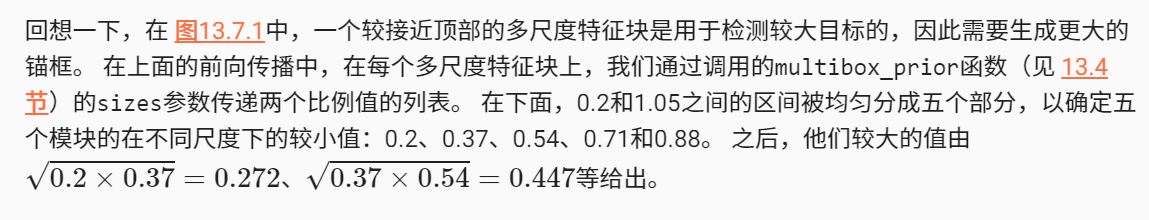

In [24]:
sizes = [[0.2, 0.272], [0.37, 0.447], [0.54, 0.619], [0.71, 0.79],
         [0.88, 0.961]]
ratios = [[1, 2, 0.5]] * 5
num_anchors = len(sizes[0]) + len(ratios[0]) - 1

In [25]:
class TinySSD(nn.Module):
    def __init__(self, num_classes, **kwargs):
        super(TinySSD, self).__init__(**kwargs)
        self.num_classes = num_classes
        idx_to_in_channels = [64, 128, 128, 128, 128]
        for i in range(5):
            # 即赋值语句self.blk_i=get_blk(i)
            setattr(self, f'blk_{i}', get_blk(i))  # 这样写能弄到循环里去
            setattr(self, f'cls_{i}', cls_predictor(idx_to_in_channels[i],
                                                    num_anchors, num_classes))
            setattr(self, f'bbox_{i}', bbox_predictor(idx_to_in_channels[i],
                                                      num_anchors))

    def forward(self, X):
        anchors, cls_preds, bbox_preds = [None] * 5, [None] * 5, [None] * 5
        for i in range(5):
            # getattr(self,'blk_%d'%i)即访问self.blk_i
            X, anchors[i], cls_preds[i], bbox_preds[i] = blk_forward(
                X, getattr(self, f'blk_{i}'), sizes[i], ratios[i],
                getattr(self, f'cls_{i}'), getattr(self, f'bbox_{i}'))
        anchors = torch.cat(anchors, dim=1)
        cls_preds = concat_preds(cls_preds)
        cls_preds = cls_preds.reshape(
            cls_preds.shape[0], -1, self.num_classes + 1)
        bbox_preds = concat_preds(bbox_preds)
        return anchors, cls_preds, bbox_preds  # 锚框四个点坐标  锚框各个类的概率  锚框四个点的偏移量

In [26]:
net = TinySSD(num_classes=1)
X = torch.zeros((32, 3, 256, 256))
anchors, cls_preds, bbox_preds = net(X)

print('output anchors:', anchors.shape)# 锚框数量和批量大小没关系，这个1是生成锚框函数最后增加的一维
print('output class preds:', cls_preds.shape)
print('output bbox preds:', bbox_preds.shape) # 5444*4
# 32*32*4+16*16*4+8*8*4+4*4*4+1*1*4 一共5444个锚框

output anchors: torch.Size([1, 5444, 4])
output class preds: torch.Size([32, 5444, 2])
output bbox preds: torch.Size([32, 21776])


In [27]:
batch_size = 32
train_iter, _ = d2l.load_data_bananas(batch_size)

read 1000 training examples
read 100 validation examples


In [28]:
device, net = d2l.try_gpu(), TinySSD(num_classes=1)
trainer = torch.optim.SGD(net.parameters(), lr=0.2, weight_decay=5e-4)

In [29]:
cls_loss = nn.CrossEntropyLoss(reduction='none') # 交叉熵 分类
bbox_loss = nn.L1Loss(reduction='none') # l1损失/绝对值损失 防止预测特别不靠谱给平方更大 预测

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    cls = cls_loss(cls_preds.reshape(-1, num_classes),  # 批量大小和锚框个数相乘
                   cls_labels.reshape(-1)).reshape(batch_size, -1).mean(dim=1)
    bbox = bbox_loss(bbox_preds * bbox_masks,
                     bbox_labels * bbox_masks).mean(dim=1)  # 偏移量这俩都是
    return cls + bbox

# 分类问题和回归问题 两个同时处理

In [30]:
def cls_eval(cls_preds, cls_labels):
    # 由于类别预测结果放在最后一维，argmax需要指定最后一维。
    return float((cls_preds.argmax(dim=-1).type(
        cls_labels.dtype) == cls_labels).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

class err 3.35e-03, bbox mae 3.29e-03
7892.0 examples/sec on cuda:0


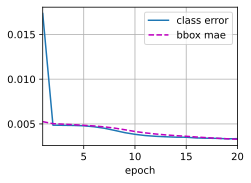

In [31]:
num_epochs, timer = 20, d2l.Timer()
animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                        legend=['class error', 'bbox mae'])
net = net.to(device)
# bbox_labels 是偏移量！！ bbox_pred是预测的偏移量
for epoch in range(num_epochs):
    # 训练精确度的和，训练精确度的和中的示例数
    # 绝对误差的和，绝对误差的和中的示例数
    metric = d2l.Accumulator(4)
    net.train()
    for features, target in train_iter:
        timer.start()
        trainer.zero_grad()
        X, Y = features.to(device), target.to(device)
        # 生成多尺度的锚框，为每个锚框预测类别和偏移量
        anchors, cls_preds, bbox_preds = net(X)
        # 为每个锚框标注类别和偏移量
        bbox_labels, bbox_masks, cls_labels = d2l.multibox_target(anchors, Y) # 真实值
        # 根据类别和偏移量的预测和标注值计算损失函数
        l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels,
                      bbox_masks)
        l.mean().backward()
        trainer.step()
        metric.add(cls_eval(cls_preds, cls_labels), cls_labels.numel(),
                   bbox_eval(bbox_preds, bbox_labels, bbox_masks),
                   bbox_labels.numel())
    cls_err, bbox_mae = 1 - metric[0] / metric[1], metric[2] / metric[3]
    animator.add(epoch + 1, (cls_err, bbox_mae))
print(f'class err {cls_err:.2e}, bbox mae {bbox_mae:.2e}')
print(f'{len(train_iter.dataset) / timer.stop():.1f} examples/sec on '
      f'{str(device)}')

In [33]:
X = torchvision.io.read_image('../data/img/banana.jpg').unsqueeze(0).float()
img = X.squeeze(0).permute(1, 2, 0).long()

In [35]:
X.shape

torch.Size([1, 3, 256, 256])

In [36]:
def predict(X):
    net.eval()
    anchors, cls_preds, bbox_preds = net(X.to(device))
    cls_probs = F.softmax(cls_preds, dim=2).permute(0, 2, 1) # 概率最大的会抑制掉别的
    output = d2l.multibox_detection(cls_probs, bbox_preds, anchors)
    idx = [i for i, row in enumerate(output[0]) if row[0] != -1]
    return output[0, idx]

output = predict(X)

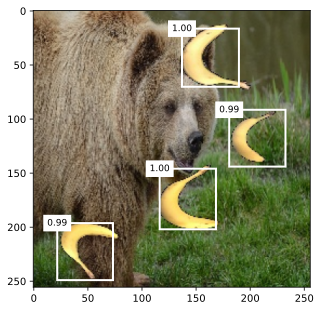

In [37]:
def display(img, output, threshold):
    d2l.set_figsize((5, 5))
    fig = d2l.plt.imshow(img)
    for row in output:
        score = float(row[1])
        if score < threshold:
            continue
        h, w = img.shape[0:2]
        bbox = [row[2:6] * torch.tensor((w, h, w, h), device=row.device)]
        d2l.show_bboxes(fig.axes, bbox, '%.2f' % score, 'w')

display(img, output.cpu(), threshold=0.9)

总结 SSD的每一层都有类预测和偏移预测 最后所有的层的锚框cat到一起来进行计算。训练的时候是同时解决分类问题和回归问题。预测的时候需要计算偏移量并且用非极大值抑制，选出概率最大的抑制掉与其iou大的 最后进行展示。网络返回的三个分别是锚框四个点坐标  锚框各个类的概率  锚框四个点的偏移量

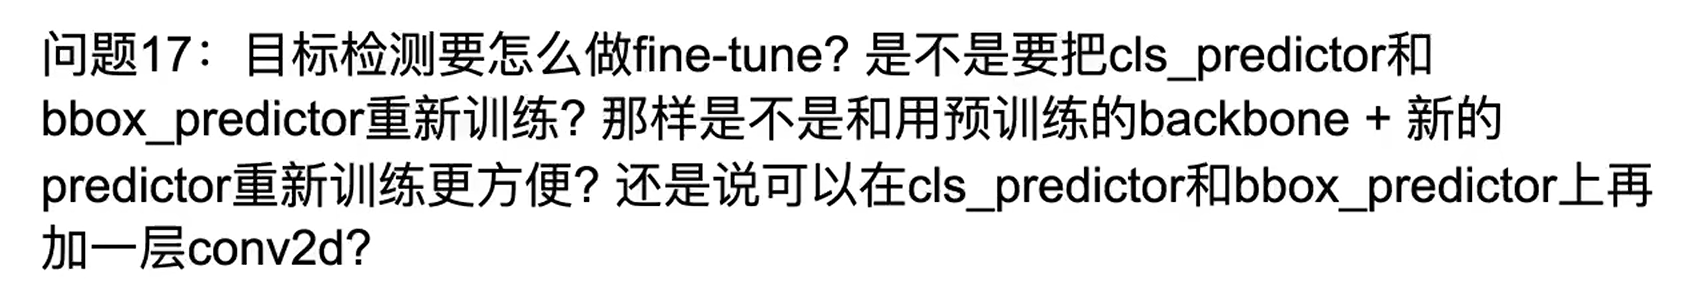
一般是把图片分类的模型作为backbone，而不是跑完的检测模型

目标检测比较好的包推荐mmdetection挺好用的，改一下配置文件可以跑好多种模型
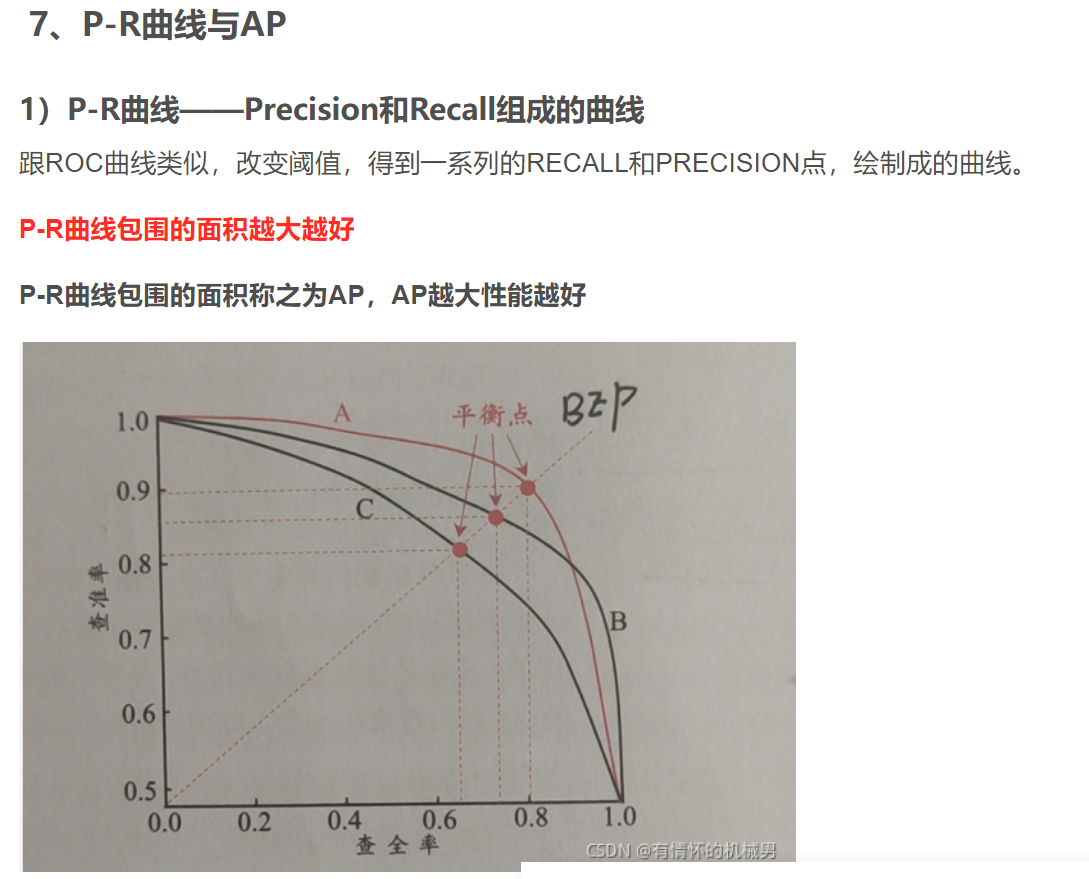
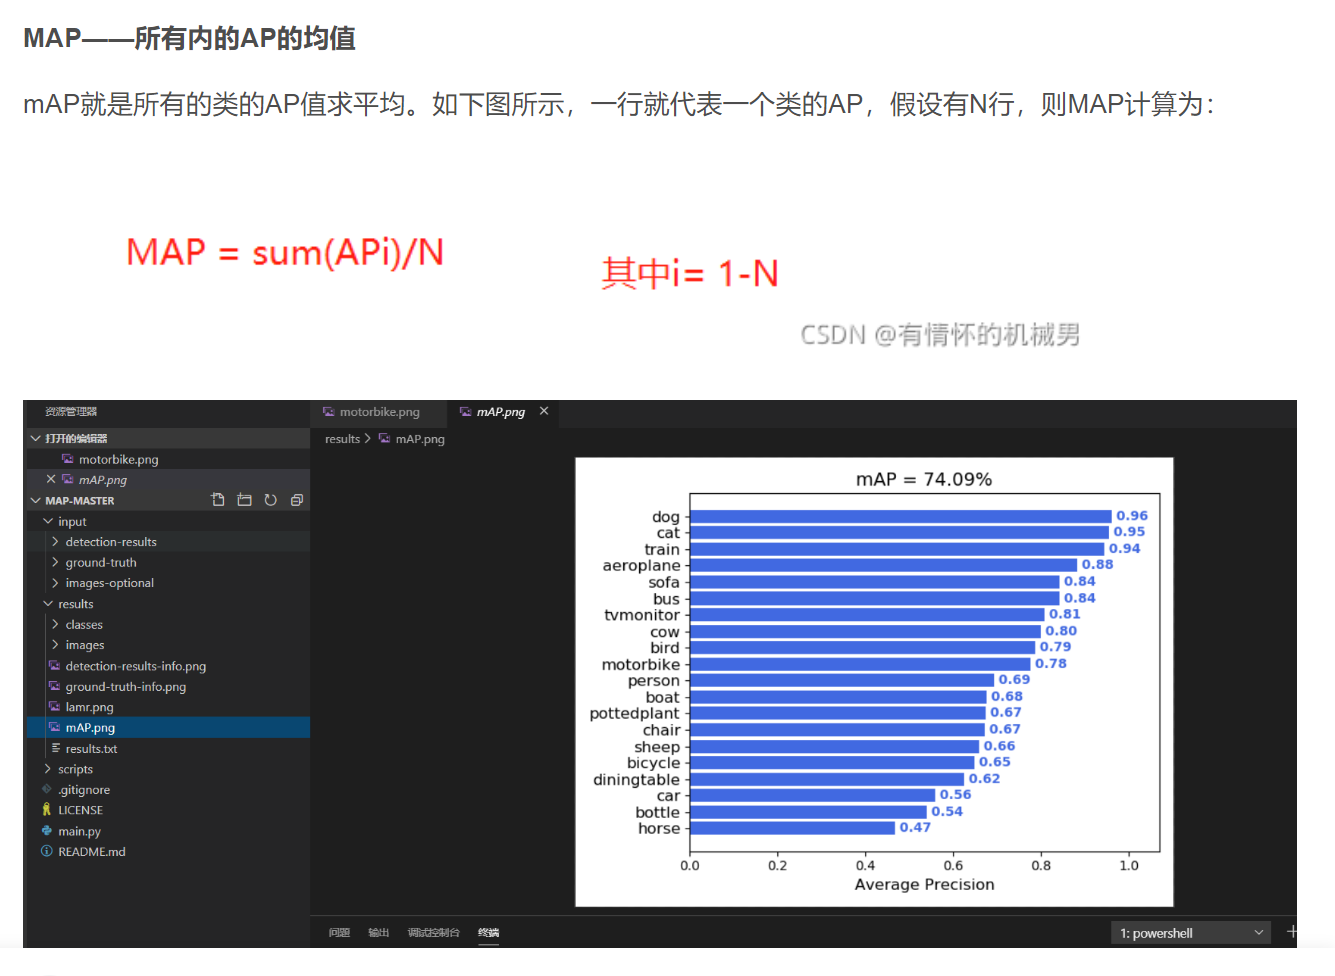
什么是AP mAP